# Avance 1. Análisis exploratorio de datos
## Avocado Insights · Equipo 4
**Proyecto:** Diagnóstico de la producción municipal de aguacate para apoyar la planeación logística sustentable en México.  
**Materia:** TC5035.10 · Proyecto integrador · Tecnológico de Monterrey.  
**Profesor del curso:** Raúl Valente Ramírez Velarde. **Sponsor:** Dr. Jorge Antonio Ascencio Gutiérrez.  
**Entrega:** 4 de octubre de 2026.

| Integrante | Matrícula |
|---|---|
| José Roberto Sánchez Rocha | A00903762 |
| Josué Águila Ramos | A01796400 |
| Roberto Perézcano Hernández | A01730502 |

### Resumen y alcance
El notebook previo documentó un cambio acordado con el sponsor: estudiar zonas productoras y, posteriormente, centros de acopio, rutas y desempeño energético. Este avance desarrolla la **base productiva de ese enfoque**: dónde se concentra la oferta, cómo varía, qué problemas de calidad existen y qué variables permiten describir perfiles municipales. No estima rutas, combustible ni emisiones sin datos observados para esas magnitudes.

Se analiza una copia pública del histórico SIAP, con atribución y hash verificable. La fuente original contiene 1980–2025; el panel municipal utiliza **2003–2023 y 2025**. Se separan 1980–2002 por falta estructural de municipio y **2024 por ambigüedad de clave en la copia**, explicada y cuantificada en §3. Se conserva íntegro el archivo recibido. No son datos sintéticos ni una descarga directa autenticada desde SIAP.

**Ejecución:** abrir desde `notebooks/` o desde la raíz del paquete, reiniciar kernel y ejecutar todas las celdas en orden. Los datos están incluidos; no se requiere internet ni credenciales. Todas las salidas se recalculan. Dependencias en `requirements.txt`.

### Índice y trazabilidad de la rúbrica
| Criterio (20 puntos cada uno) | Evidencia |
|---|---|
| Estructura de datos | §2–3: diccionario, tipos, dimensiones, estadísticas, frecuencias, cardinalidad y faltantes |
| Univariante | §5: histogramas y boxplots de las 7 magnitudes; barras de categorías |
| Bi/multivariante | §6–7: Pearson, Spearman, mapas de calor, dispersión, categorías y evolución temporal |
| Preprocesamiento | §3–4 y §8: granularidad, faltantes estructurales, extremos, logaritmos y alta cardinalidad |
| Conclusiones | §10: respuestas con cifras, implicaciones, limitaciones y decisiones |

**Preguntas:** ¿qué municipios concentran oferta?, ¿cómo se relacionan superficie, producción y rendimiento?, ¿hay sesgo y atípicos?, ¿qué diferencias existen por modalidad?, ¿cómo evoluciona la producción anual?, ¿qué falta para optimizar la logística?

## 1. Entorno reproducible y fuentes
**Fuente original:** DGSIAP/SADER, estadística anual de producción agrícola. El portal confirma disponibilidad municipal desde 2003.  
**Acceso a los bytes utilizados:** repositorio público `lapanquecita/aguacate`, de Montse; archivo `data/siap_produccion.csv`, commit `649fc58cc0975fc9f2ec547369379c36018eb3e9` (20 de septiembre de 2026). El archivo se incluye sin modificar y se conserva la licencia MIT del distribuidor. Los análisis y textos de esta libreta son específicos de esta entrega.

La descarga directa oficial devolvió HTTP 502 durante la preparación; por ello se utiliza esa copia secundaria **sin atribuirle validación oficial integral**. Se contrasta una selección de cifras de 2023 contra SEDARH (§3). El hash garantiza que todos ejecutan los mismos bytes, no garantiza veracidad. Consulta: 4 de octubre de 2026, hora de México.

Fuentes y documentación completas en §11 y `data/proveniencia.json`.

In [1]:
from pathlib import Path
import hashlib, json, sys, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidatas = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidatas if (p / 'data/raw/siap_produccion.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Extrae el paquete completo y abre notebooks/Avance1.Equipo4.ipynb. Se requiere data/raw/siap_produccion.csv.')
OUT = ROOT / 'resultados'; OUT.mkdir(exist_ok=True)
PRO = ROOT / 'data/processed'; PRO.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep', font_scale=.95)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

def tabla(df, nombre, mostrar=True):
    df.to_csv(OUT / (nombre + '.csv'), index=False, encoding='utf-8-sig')
    if mostrar: display(df)

def figura(nombre):
    plt.tight_layout()
    plt.savefig(OUT / (nombre + '.png'), bbox_inches='tight')
    plt.show()
    plt.close('all')

def nota(texto): display(Markdown(texto))

meta = json.loads((ROOT / 'data/proveniencia.json').read_text())
archivo = ROOT / 'data/raw/siap_produccion.csv'
assert hashlib.sha256(archivo.read_bytes()).hexdigest() == meta['sha256'], 'Los bytes no coinciden con la versión documentada.'
raw = pd.read_csv(archivo)
versiones = {p: importlib.metadata.version(p) for p in ['pandas','numpy','matplotlib','seaborn','scikit-learn']}
print('Python:', platform.python_version(), '\nPaquetes:', versiones)
print('Fuente original:', meta['fuente_original'])
print('SHA-256:', meta['sha256'])
print('Forma original:', raw.shape)
assert raw.shape == (15474, 24)
assert set(raw['CULTIVO']) == {'Aguacate'}
assert set(raw['UNIDAD_MEDIDA']) == {'Tonelada'}
display(raw.head(5))

Python: 3.12.14 
Paquetes: {'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8', 'seaborn': '0.13.2', 'scikit-learn': '1.8.0'}
Fuente original: DGSIAP/SADER, Cierre de la producción agrícola
SHA-256: f195190c043409188741ea4a6a2bbb44343aaeaa1f2e02dc17b6bd5f394f9dd3
Forma original: (15474, 24)


,AÑO,CVE_ENT,ENTIDAD,CVE_MUN,MUNICIPIO,CVE_DDR,DISTRITO,CVE_CADER,CADER,CVE_CICLO,CICLE,CVE_MODALIDAD,MODALIDAD,CVE_UNIDAD,UNIDAD_MEDIDA,CVE_CULTIVO,CULTIVO,SUPERFICIE_SEMBRADA,SUPERFICIE_COSECHADA,SUPERFICIE_SINIESTRADA,VOLUMEN_PRODUCCION,RENDIMIENTO,PRECIO,VALOR_PRODUCCION
0,1980,3,Baja California Sur,999,NaN,NaN,NaN,NaN,NaN,3,Perennes,1,Riego,200201,Tonelada,5060000,Aguacate,378.000,300.000,0.000,833.000,2.780,18.790,"15,652.000"
1,1980,4,Campeche,999,NaN,NaN,NaN,NaN,NaN,3,Perennes,2,Temporal,200201,Tonelada,5060000,Aguacate,264.000,264.000,0.000,"2,112.000",8.000,4.800,"10,138.000"
2,1980,6,Colima,999,NaN,NaN,NaN,NaN,NaN,3,Perennes,1,Riego,200201,Tonelada,5060000,Aguacate,866.000,239.000,0.000,792.000,3.310,8.250,"6,532.000"
3,1980,7,Chiapas,999,NaN,NaN,NaN,NaN,NaN,3,Perennes,2,Temporal,200201,Tonelada,5060000,Aguacate,"3,925.000","3,925.000",0.000,"36,606.000",9.330,7.200,"263,563.000"
4,1980,10,Durango,999,NaN,NaN,NaN,NaN,NaN,3,Perennes,1,Riego,200201,Tonelada,5060000,Aguacate,175.000,175.000,0.000,455.000,2.600,8.000,"3,640.000"


## 2. Estructura, diccionario y estadísticas de todas las variables
La fila fuente representa un registro anual por ubicación administrativa, ciclo, modalidad hídrica y cultivo. **No equivale necesariamente a un municipio completo**: un municipio puede aparecer en varios CADER o modalidades. Las claves son identificadores nominales, no magnitudes para correlacionar. El conjunto no tiene imágenes ni clases objetivo de clasificación.

Para las magnitudes se usan hectáreas, toneladas, t/ha, pesos por tonelada y pesos corrientes. La escala monetaria de la copia se verifica con la identidad `volumen × precio ≈ valor`; no debe confundirse con publicaciones que expresan valor en miles de pesos. Los precios históricos no están deflactados.

In [2]:
N = ['SUPERFICIE_SEMBRADA','SUPERFICIE_COSECHADA','SUPERFICIE_SINIESTRADA',
     'VOLUMEN_PRODUCCION','RENDIMIENTO','PRECIO','VALOR_PRODUCCION']
C = [c for c in raw if c not in N + ['AÑO']]
conceptos = {
'AÑO': ('Año agrícola', 'año', 'Temporal discreta'),
'CVE_ENT': ('Clave de entidad federativa','código','Identificador'),
'ENTIDAD': ('Nombre de la entidad','categoría','Nominal'),
'CVE_MUN': ('Clave de municipio dentro de la entidad; 999 en histórico sin municipio','código','Identificador'),
'MUNICIPIO': ('Nombre municipal','categoría','Nominal'),
'CVE_DDR': ('Clave del Distrito de Desarrollo Rural','código','Identificador'),
'DISTRITO': ('Nombre del Distrito de Desarrollo Rural','categoría','Nominal'),
'CVE_CADER': ('Clave del Centro de Apoyo al Desarrollo Rural; no es globalmente única','código','Identificador'),
'CADER': ('Nombre del Centro de Apoyo al Desarrollo Rural; no es un centro de acopio','categoría','Nominal'),
'CVE_CICLO': ('Clave de ciclo agrícola','código','Identificador'),
'CICLE': ('Ciclo agrícola; nombre de columna conservado de la copia','categoría','Nominal'),
'CVE_MODALIDAD': ('Clave de modalidad hídrica','código','Identificador'),
'MODALIDAD': ('Riego o temporal','categoría','Nominal'),
'CVE_UNIDAD': ('Clave de unidad de medida','código','Identificador'),
'UNIDAD_MEDIDA': ('Unidad del volumen','categoría','Nominal'),
'CVE_CULTIVO': ('Clave del cultivo','código','Identificador'),
'CULTIVO': ('Nombre del cultivo','categoría','Nominal'),
'SUPERFICIE_SEMBRADA': ('Área sembrada','ha','Cuantitativa'),
'SUPERFICIE_COSECHADA': ('Área cosechada','ha','Cuantitativa'),
'SUPERFICIE_SINIESTRADA': ('Área reportada como siniestrada','ha','Cuantitativa'),
'VOLUMEN_PRODUCCION': ('Producción anual reportada','t','Cuantitativa'),
'RENDIMIENTO': ('Producción / superficie cosechada','t/ha','Razón derivada'),
'PRECIO': ('Precio medio rural','MXN/t corrientes','Razón / magnitud'),
'VALOR_PRODUCCION': ('Valor nominal de producción','MXN corrientes','Cuantitativa')}
diccionario = pd.DataFrame([{'variable': c, 'descripcion': conceptos[c][0], 'unidad': conceptos[c][1],
 'rol': conceptos[c][2], 'tipo_pandas': str(raw[c].dtype), 'distintos': raw[c].nunique(),
 'faltantes': raw[c].isna().sum(), 'faltantes_pct': raw[c].isna().mean()*100} for c in raw])
tabla(diccionario,'01_diccionario_y_estructura')
resumen_raw = raw[N+['AÑO']].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T.reset_index(names='variable')
tabla(resumen_raw, '02_estadisticas_originales')
frecuencias=[]
for col in C:
    vc=raw[col].astype('string').fillna('[Ausente]').value_counts(dropna=False)
    frecuencias.extend({'variable':col,'categoria':str(k),'n':int(v),'porcentaje':v/len(raw)*100} for k,v in vc.items())
freq=pd.DataFrame(frecuencias)
tabla(freq,'03_frecuencias_todas_categorias',False)
# Se muestran todas las variables nominales. El CSV conserva TODAS sus clases.
display(freq.groupby('variable',sort=False).head(3).reset_index(drop=True))
nota('Las tablas 01–03 cubren las 24 columnas: resumen cuantitativo para magnitudes/año y frecuencias para todas las claves y categorías. El CSV 03 contiene las clases completas; aquí se muestran las tres más frecuentes por variable para legibilidad.')

,variable,descripcion,unidad,rol,tipo_pandas,distintos,faltantes,faltantes_pct
0,AÑO,Año agrícola,año,Temporal discreta,int64,46,0,0.000
1,CVE_ENT,Clave de entidad federativa,código,Identificador,int64,31,0,0.000
2,ENTIDAD,Nombre de la entidad,categoría,Nominal,object,31,0,0.000
3,CVE_MUN,Clave de municipio dentro de la entidad; 999 e...,código,Identificador,int64,301,0,0.000
4,MUNICIPIO,Nombre municipal,categoría,Nominal,object,763,981,6.340
5,CVE_DDR,Clave del Distrito de Desarrollo Rural,código,Identificador,float64,116,981,6.340
6,DISTRITO,Nombre del Distrito de Desarrollo Rural,categoría,Nominal,object,116,981,6.340
7,CVE_CADER,Clave del Centro de Apoyo al Desarrollo Rural;...,código,Identificador,float64,10,981,6.340
8,CADER,Nombre del Centro de Apoyo al Desarrollo Rural...,categoría,Nominal,object,295,981,6.340
9,CVE_CICLO,Clave de ciclo agrícola,código,Identificador,int64,1,0,0.000


,variable,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
0,SUPERFICIE_SEMBRADA,"15,474.000",398.931,"2,216.166",0.000,0.750,6.000,21.000,103.000,"1,481.350","7,629.860","65,618.000"
1,SUPERFICIE_COSECHADA,"15,474.000",361.702,"2,034.045",0.000,0.000,4.000,16.000,79.000,"1,346.200","7,212.750","45,935.000"
2,SUPERFICIE_SINIESTRADA,"15,474.000",0.009,0.411,0.000,0.000,0.000,0.000,0.000,0.000,0.000,36.110
3,VOLUMEN_PRODUCCION,"15,474.000","3,612.137","20,303.175",0.000,0.000,21.000,93.155,654.875,"12,809.835","81,404.644","502,639.000"
4,RENDIMIENTO,"15,441.000",7.305,4.455,0.000,0.000,4.000,7.000,9.950,14.070,24.772,41.000
5,PRECIO,"15,441.000","11,296.470","7,877.100",0.000,0.000,"5,000.000","10,401.590","16,750.000","25,016.240","33,161.102","43,588.640"
6,VALOR_PRODUCCION,"15,474.000","46,207,277.634","239,525,271.441",0.000,0.000,"167,085.540","859,087.915","6,384,000.000","156,237,899.345","1,113,197,961.620","5,055,253,869.600"
7,AÑO,"15,474.000","2,013.661",8.783,"1,980.000","1,983.000","2,008.000","2,015.000","2,021.000","2,024.350","2,025.000","2,025.000"


,variable,categoria,n,porcentaje
0,CVE_ENT,20,3120,20.163
1,CVE_ENT,14,1867,12.065
2,CVE_ENT,16,1858,12.007
3,ENTIDAD,Oaxaca,3120,20.163
4,ENTIDAD,Jalisco,1867,12.065
5,ENTIDAD,Michoacán,1858,12.007
6,CVE_MUN,999,981,6.340
7,CVE_MUN,4,291,1.881
8,CVE_MUN,1,289,1.868
9,MUNICIPIO,[Ausente],981,6.340


Las tablas 01–03 cubren las 24 columnas: resumen cuantitativo para magnitudes/año y frecuencias para todas las claves y categorías. El CSV 03 contiene las clases completas; aquí se muestran las tres más frecuentes por variable para legibilidad.

## 3. Auditoría: faltantes, granularidad, duplicados y contraste externo
Se diferencia entre duplicación exacta y repetición de una clave incompleta. Dos modalidades de un municipio son registros válidos distintos. Cuando se repite incluso la clave administrativa completa, sin una dimensión adicional que explique las filas, la ambigüedad debe resolverse antes de modelar.

Duplicados exactos originales: 0
Repeticiones adicionales de clave completa en 2024: 137
Filas involucradas en claves ambiguas: 263


,AÑO,registros,municipio_ausente,rendimiento_ausente,precio_ausente,filas_clave_ambigua,produccion_t
0,1980,37,37,0,0,0,"434,259.000"
1,1981,39,39,0,0,0,"459,212.000"
2,1982,41,41,0,0,0,"484,137.000"
3,1983,41,41,0,0,0,"425,139.000"
4,1984,41,41,0,0,0,"430,744.000"
5,1985,39,39,0,0,0,"565,309.000"
6,1986,42,42,0,0,0,"627,819.000"
7,1987,44,44,0,0,0,"520,162.000"
8,1988,44,44,0,0,0,"682,861.000"
9,1989,44,44,0,0,0,"470,196.000"


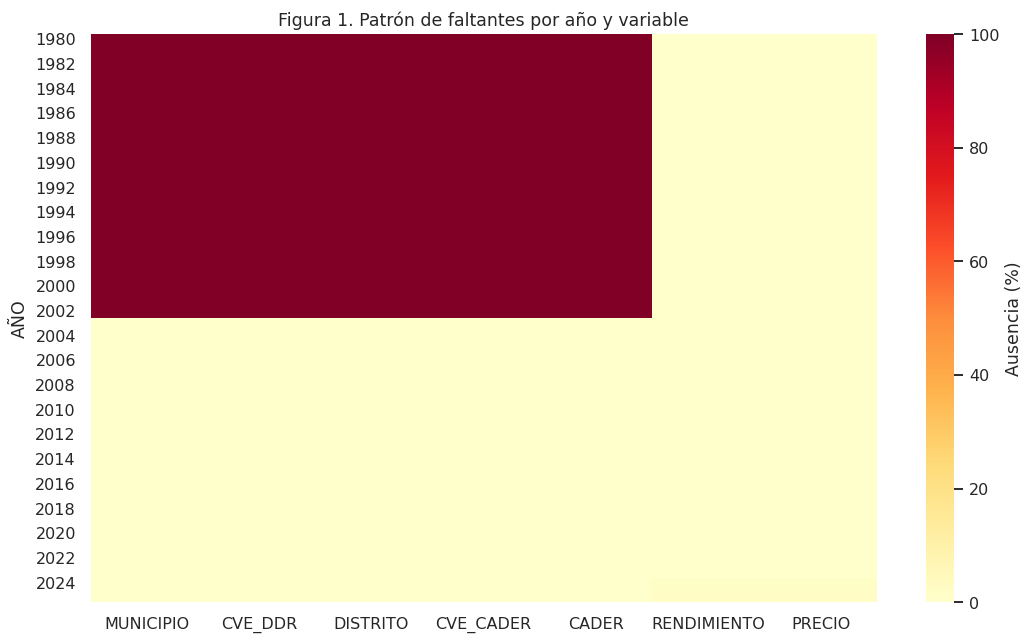

**Decisión ejecutada:** 981 registros históricos sin nivel municipal se separan; los 900 registros de 2024 quedan en cuarentena. La clave repetida podría representar desagregaciones omitidas en la copia, no demuestra duplicación errónea. No se suman ni borran arbitrariamente: se excluye el año completo del panel principal hasta aclararlo con el archivo oficial. No se interpola 2024.

In [3]:
clave = ['AÑO','CVE_ENT','CVE_MUN','CVE_DDR','CVE_CADER','CVE_CICLO','CVE_MODALIDAD','CVE_CULTIVO','CVE_UNIDAD']
raw['clave_ambigua'] = raw.duplicated(clave,keep=False)
calidad_anual = raw.groupby('AÑO').agg(registros=('AÑO','size'),
 municipio_ausente=('MUNICIPIO',lambda x:x.isna().sum()),
 rendimiento_ausente=('RENDIMIENTO',lambda x:x.isna().sum()),
 precio_ausente=('PRECIO',lambda x:x.isna().sum()),
 filas_clave_ambigua=('clave_ambigua','sum'), produccion_t=('VOLUMEN_PRODUCCION','sum')).reset_index()
tabla(calidad_anual,'04_calidad_por_anio')
print('Duplicados exactos originales:', raw.drop(columns='clave_ambigua').duplicated().sum())
print('Repeticiones adicionales de clave completa en 2024:', raw.loc[raw['AÑO'].eq(2024)].duplicated(clave).sum())
print('Filas involucradas en claves ambiguas:', int(raw.clave_ambigua.sum()))
fig, ax = plt.subplots(figsize=(10,6))
missing_by_year = raw.groupby('AÑO')[['MUNICIPIO','CVE_DDR','DISTRITO','CVE_CADER','CADER','RENDIMIENTO','PRECIO']].agg(lambda s:s.isna().mean()*100)
sns.heatmap(missing_by_year, cmap='YlOrRd', ax=ax, cbar_kws={'label':'Ausencia (%)'})
ax.set_title('Figura 1. Patrón de faltantes por año y variable')
figura('fig01_faltantes')
raw.loc[raw['AÑO'].eq(2024)].drop(columns='clave_ambigua').to_csv(PRO/'cuarentena_2024.csv', index=False)
nota(f'**Decisión ejecutada:** {int(raw["AÑO"].lt(2003).sum()):,} registros históricos sin nivel municipal se separan; los {int(raw["AÑO"].eq(2024).sum()):,} registros de 2024 quedan en cuarentena. La clave repetida podría representar desagregaciones omitidas en la copia, no demuestra duplicación errónea. No se suman ni borran arbitrariamente: se excluye el año completo del panel principal hasta aclararlo con el archivo oficial. No se interpola 2024.')

In [4]:
# Contraste parcial contra SEDARH: publicación gubernamental del cierre 2023.
# Fuente: https://sedarh.gob.mx/seia/cultivos/aguacate
r23=raw.loc[raw['AÑO'].eq(2023)]
slp=r23.loc[r23['ENTIDAD'].eq('San Luis Potosí')]
contrastes=[
 ('SLP producción 2023 (t)', slp.VOLUMEN_PRODUCCION.sum(),428.90,.02),
 ('SLP superficie sembrada 2023 (ha)',slp.SUPERFICIE_SEMBRADA.sum(),141.00,.02),
 ('SLP valor 2023 (miles MXN)',slp.VALOR_PRODUCCION.sum()/1000,7243.13,.02),
 ('México superficie sembrada 2023 (ha)',r23.SUPERFICIE_SEMBRADA.sum(),264589.06,.02),
 ('México valor 2023 (miles MXN)',r23.VALOR_PRODUCCION.sum()/1000,60097063.91,.02)]
contraste=pd.DataFrame(contrastes,columns=['indicador','copia','publicacion_oficial','tolerancia'])
contraste['diferencia']=contraste.copia-contraste.publicacion_oficial
contraste['coincide_redondeo']=contraste.diferencia.abs()<=contraste.tolerancia
tabla(contraste,'05_contraste_oficial')
assert contraste.coincide_redondeo.all()
nota('La tolerancia admite redondeos de publicación. Coincidir en estos agregados aumenta la confianza en unidades y transcripción de 2023; no valida todos los municipios ni los demás años.')

,indicador,copia,publicacion_oficial,tolerancia,diferencia,coincide_redondeo
0,SLP producción 2023 (t),428.900,428.900,0.020,0.000,True
1,SLP superficie sembrada 2023 (ha),141.000,141.000,0.020,0.000,True
2,SLP valor 2023 (miles MXN),"7,243.135","7,243.130",0.020,0.005,True
3,México superficie sembrada 2023 (ha),"264,589.060","264,589.060",0.020,0.000,True
4,México valor 2023 (miles MXN),"60,097,063.914","60,097,063.910",0.020,0.004,True


La tolerancia admite redondeos de publicación. Coincidir en estos agregados aumenta la confianza en unidades y transcripción de 2023; no valida todos los municipios ni los demás años.

## 4. Preprocesamiento ejecutado y justificado
1. Se conserva el archivo original y se crea una copia de trabajo municipal; se normalizan espacios y claves geográficas.  
2. Se separan periodos con diferente granularidad y el año ambiguo.  
3. Los valores negativos y superficies incoherentes se auditan; se exige que la clave restante sea única.  
4. Rendimiento y precio se recalculan desde cantidades aditivas **solo cuando existe denominador positivo**. Un registro sin cosecha no recibe la mediana de otro municipio: se conserva la producción cero y las razones quedan como no aplicables.  
5. Se agrupan registros administrativos válidos a municipio–año–modalidad y municipio–año. Se suman superficies, volumen y valor; las razones se recalculan de los totales. Nunca se promedian rendimientos sin ponderar.

Se considera una ausencia por denominador cero como **estructural**; esto se comprueba en la tabla. No se inyectan faltantes ni errores artificiales para demostrar limpieza.

In [5]:
d = raw.loc[raw['AÑO'].ge(2003) & raw['AÑO'].ne(2024)].drop(columns='clave_ambigua').copy()
for c in C:
    if d[c].dtype == 'object': d[c]=d[c].str.strip()
d['CVEGEO']=d.CVE_ENT.astype(int).astype(str).str.zfill(2)+d.CVE_MUN.astype(int).astype(str).str.zfill(3)
assert not d.duplicated(clave).any()
assert not d[N].lt(0).any().any()
assert (d.SUPERFICIE_COSECHADA<=d.SUPERFICIE_SEMBRADA+.011).all()
assert (d.SUPERFICIE_SINIESTRADA<=d.SUPERFICIE_SEMBRADA+.011).all()
assert d.loc[d.SUPERFICIE_COSECHADA.eq(0),'VOLUMEN_PRODUCCION'].eq(0).all()

faltantes_contexto=d.assign(sin_cosecha=d.SUPERFICIE_COSECHADA.eq(0)).groupby(['AÑO','sin_cosecha']).agg(
 filas=('AÑO','size'),rendimiento_ausente=('RENDIMIENTO',lambda s:s.isna().sum()),
 precio_ausente=('PRECIO',lambda s:s.isna().sum())).reset_index()
tabla(faltantes_contexto,'06_contexto_faltantes',False)
display(faltantes_contexto.loc[faltantes_contexto.sin_cosecha].tail(8))
antes=d[N].isna().sum()
d['SIN_COSECHA']=d.SUPERFICIE_COSECHADA.eq(0)
d['RENDIMIENTO']=d.VOLUMEN_PRODUCCION.div(d.SUPERFICIE_COSECHADA.where(d.SUPERFICIE_COSECHADA.gt(0)))
d['PRECIO']=d.VALOR_PRODUCCION.div(d.VOLUMEN_PRODUCCION.where(d.VOLUMEN_PRODUCCION.gt(0)))
despues=d[N].isna().sum()
tabla(pd.DataFrame({'variable':N,'ausentes_antes':antes.values,'no_aplicables_despues':despues.values}), '07_antes_despues')
assert d.loc[~d.SIN_COSECHA,['RENDIMIENTO','PRECIO']].notna().all().all()
A=['SUPERFICIE_SEMBRADA','SUPERFICIE_COSECHADA','SUPERFICIE_SINIESTRADA','VOLUMEN_PRODUCCION','VALOR_PRODUCCION']
keys=['AÑO','CVEGEO','ENTIDAD','MUNICIPIO']
mod=d.groupby(keys+['MODALIDAD'],as_index=False)[A].sum()
mun=d.groupby(keys,as_index=False)[A].sum()
for frame in [mod,mun]:
    frame['RENDIMIENTO']=frame.VOLUMEN_PRODUCCION.div(frame.SUPERFICIE_COSECHADA.where(frame.SUPERFICIE_COSECHADA.gt(0)))
    frame['PRECIO']=frame.VALOR_PRODUCCION.div(frame.VOLUMEN_PRODUCCION.where(frame.VOLUMEN_PRODUCCION.gt(0)))
    frame['SIN_COSECHA']=frame.SUPERFICIE_COSECHADA.eq(0)
assert not mun.duplicated(['AÑO','CVEGEO']).any()
assert np.isclose(d.VOLUMEN_PRODUCCION.sum(),mun.VOLUMEN_PRODUCCION.sum())
mun.to_csv(PRO/'municipio_anio_limpio.csv',index=False,encoding='utf-8-sig')
mod.to_csv(PRO/'municipio_anio_modalidad.csv',index=False,encoding='utf-8-sig')
actual=mun.loc[mun['AÑO'].eq(2025)].copy()
activos=actual.loc[actual.VOLUMEN_PRODUCCION.gt(0)].copy()
nota(f'**Resultado:** {len(d):,} registros fuente elegibles → {len(mun):,} observaciones municipio–año. En 2025 hay {len(actual):,} municipios registrados y {len(activos):,} con producción positiva. Se conservaron los ceros observados, sin imputar producción. Los faltantes de razones ahora tienen una regla uniforme y explícita.')

,AÑO,sin_cosecha,filas,rendimiento_ausente,precio_ausente
29,2017,True,50,0,0
31,2018,True,56,0,0
33,2019,True,49,0,0
35,2020,True,40,0,0
37,2021,True,40,0,0
39,2022,True,31,0,0
41,2023,True,16,0,0
43,2025,True,16,16,16


,variable,ausentes_antes,no_aplicables_despues
0,SUPERFICIE_SEMBRADA,0,0
1,SUPERFICIE_COSECHADA,0,0
2,SUPERFICIE_SINIESTRADA,0,0
3,VOLUMEN_PRODUCCION,0,0
4,RENDIMIENTO,16,987
5,PRECIO,16,987
6,VALOR_PRODUCCION,0,0


**Resultado:** 13,593 registros fuente elegibles → 11,665 observaciones municipio–año. En 2025 hay 655 municipios registrados y 644 con producción positiva. Se conservaron los ceros observados, sin imputar producción. Los faltantes de razones ahora tienen una regla uniforme y explícita.

## 5. Análisis univariante
El corte transversal de **2025** evita contar repetidamente un municipio como si fuera una observación independiente en las gráficas distributivas. Las siete magnitudes se inspeccionan; no aplicables se excluyen solo de la gráfica de esa razón y se reportan. Se utiliza desviación estándar muestral (`ddof=1`) y **exceso de curtosis de Fisher** (normal ≈ 0).

,variable,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,asimetria,curtosis_exceso,coef_variacion,desviacion_mayor_media,no_aplicables
0,SUPERFICIE_SEMBRADA,655.000,409.637,"1,959.707",0.000,1.000,7.000,25.000,99.750,"1,587.550","8,041.660","25,562.000",8.714,86.471,4.784,True,0
1,SUPERFICIE_COSECHADA,655.000,390.321,"1,924.337",0.000,0.000,6.000,22.000,86.250,"1,484.450","7,957.900","25,075.000",8.813,87.753,4.930,True,0
2,SUPERFICIE_SINIESTRADA,655.000,0.046,0.821,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,22.546,538.831,17.921,True,0
3,VOLUMEN_PRODUCCION,655.000,"4,263.330","21,416.305",0.000,0.000,41.875,171.720,778.000,"16,192.993","94,032.901","268,975.900",8.563,81.661,5.023,True,0
4,RENDIMIENTO,644.000,8.676,3.467,2.970,3.500,6.683,8.200,10.407,13.962,24.088,29.800,2.200,9.570,0.400,False,11
5,PRECIO,644.000,"18,439.628","5,328.986","7,695.740","8,041.570","14,977.475","18,172.405","22,099.384","27,786.944","29,595.819","30,000.000",0.105,-0.620,0.289,False,11
6,VALOR_PRODUCCION,655.000,"90,976,584.701","469,191,841.174",0.000,0.000,"715,840.155","3,025,059.050","15,326,848.615","315,285,557.387","2,101,753,360.712","5,943,473,380.600",8.684,84.291,5.157,True,0


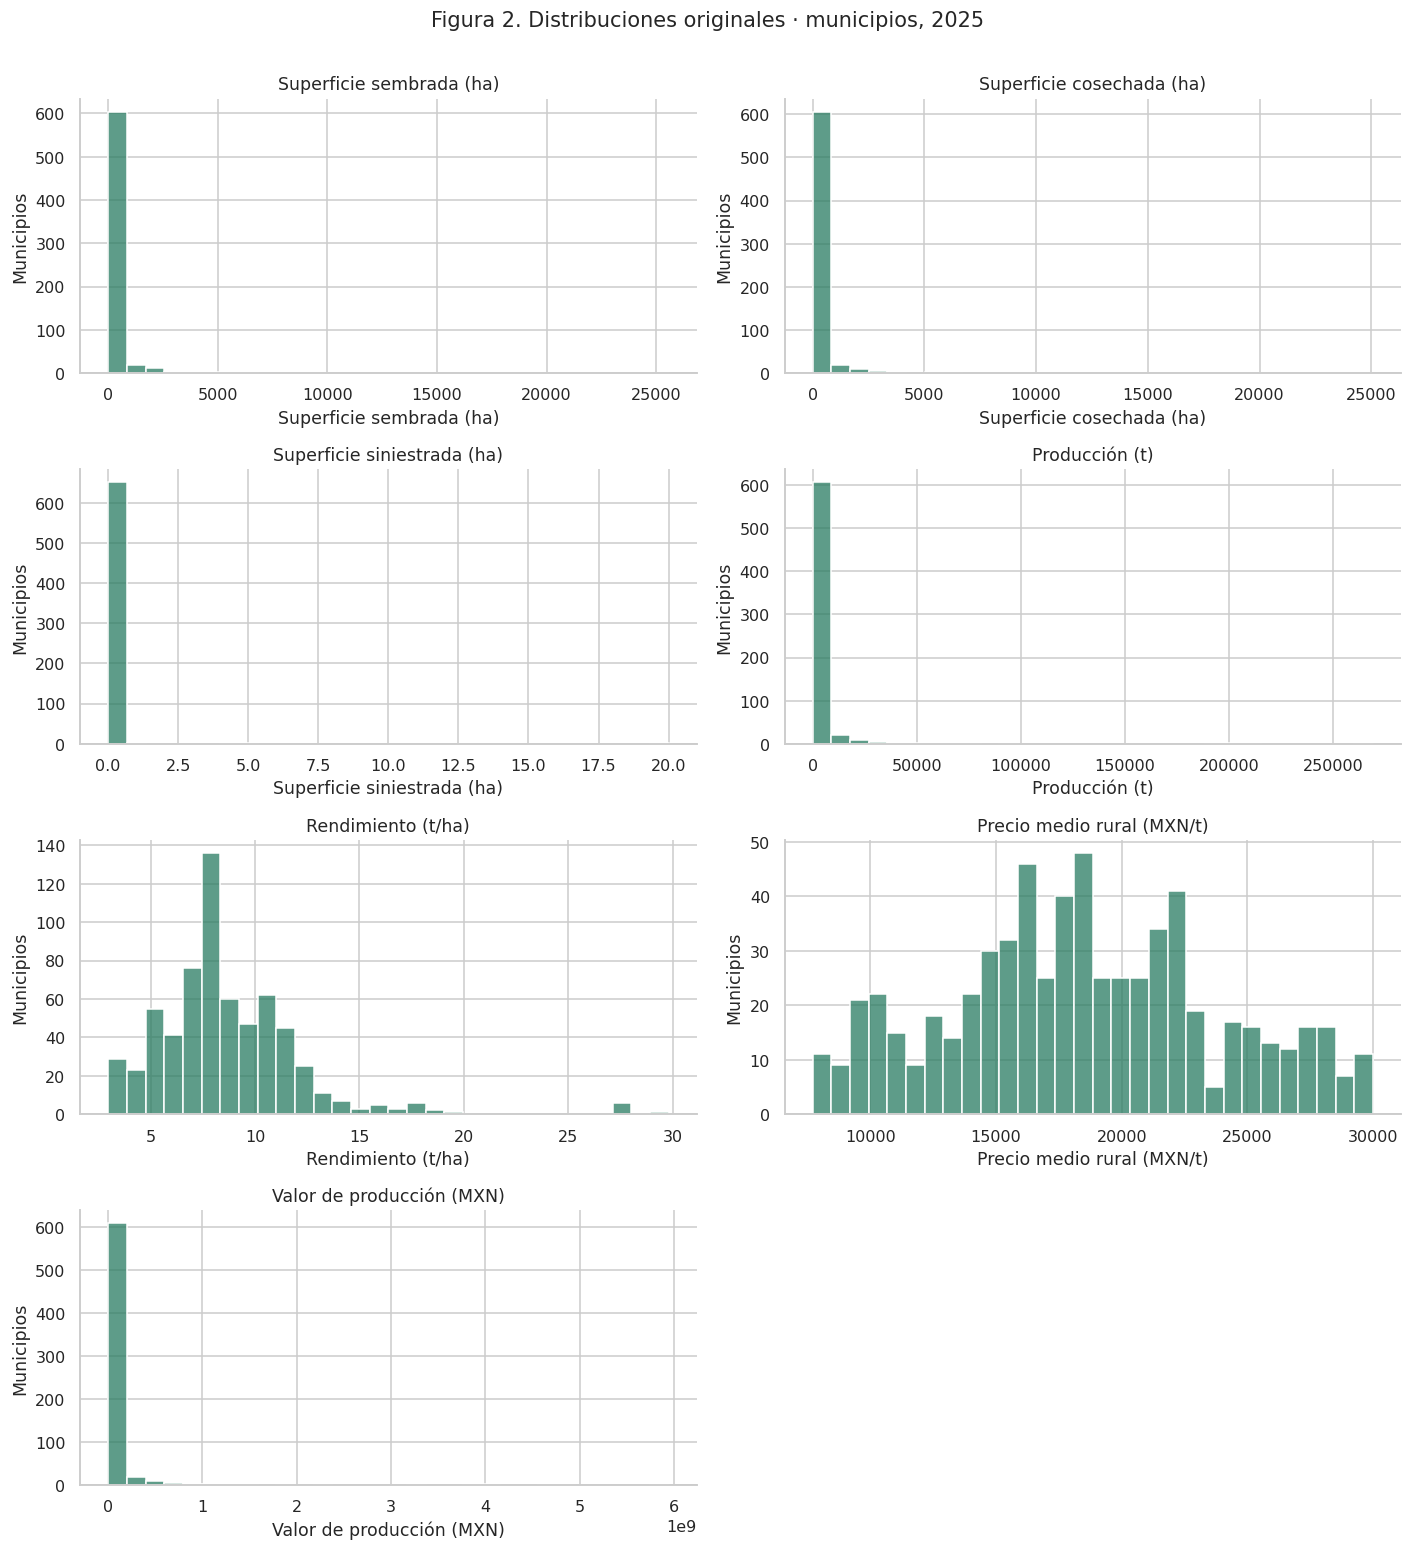

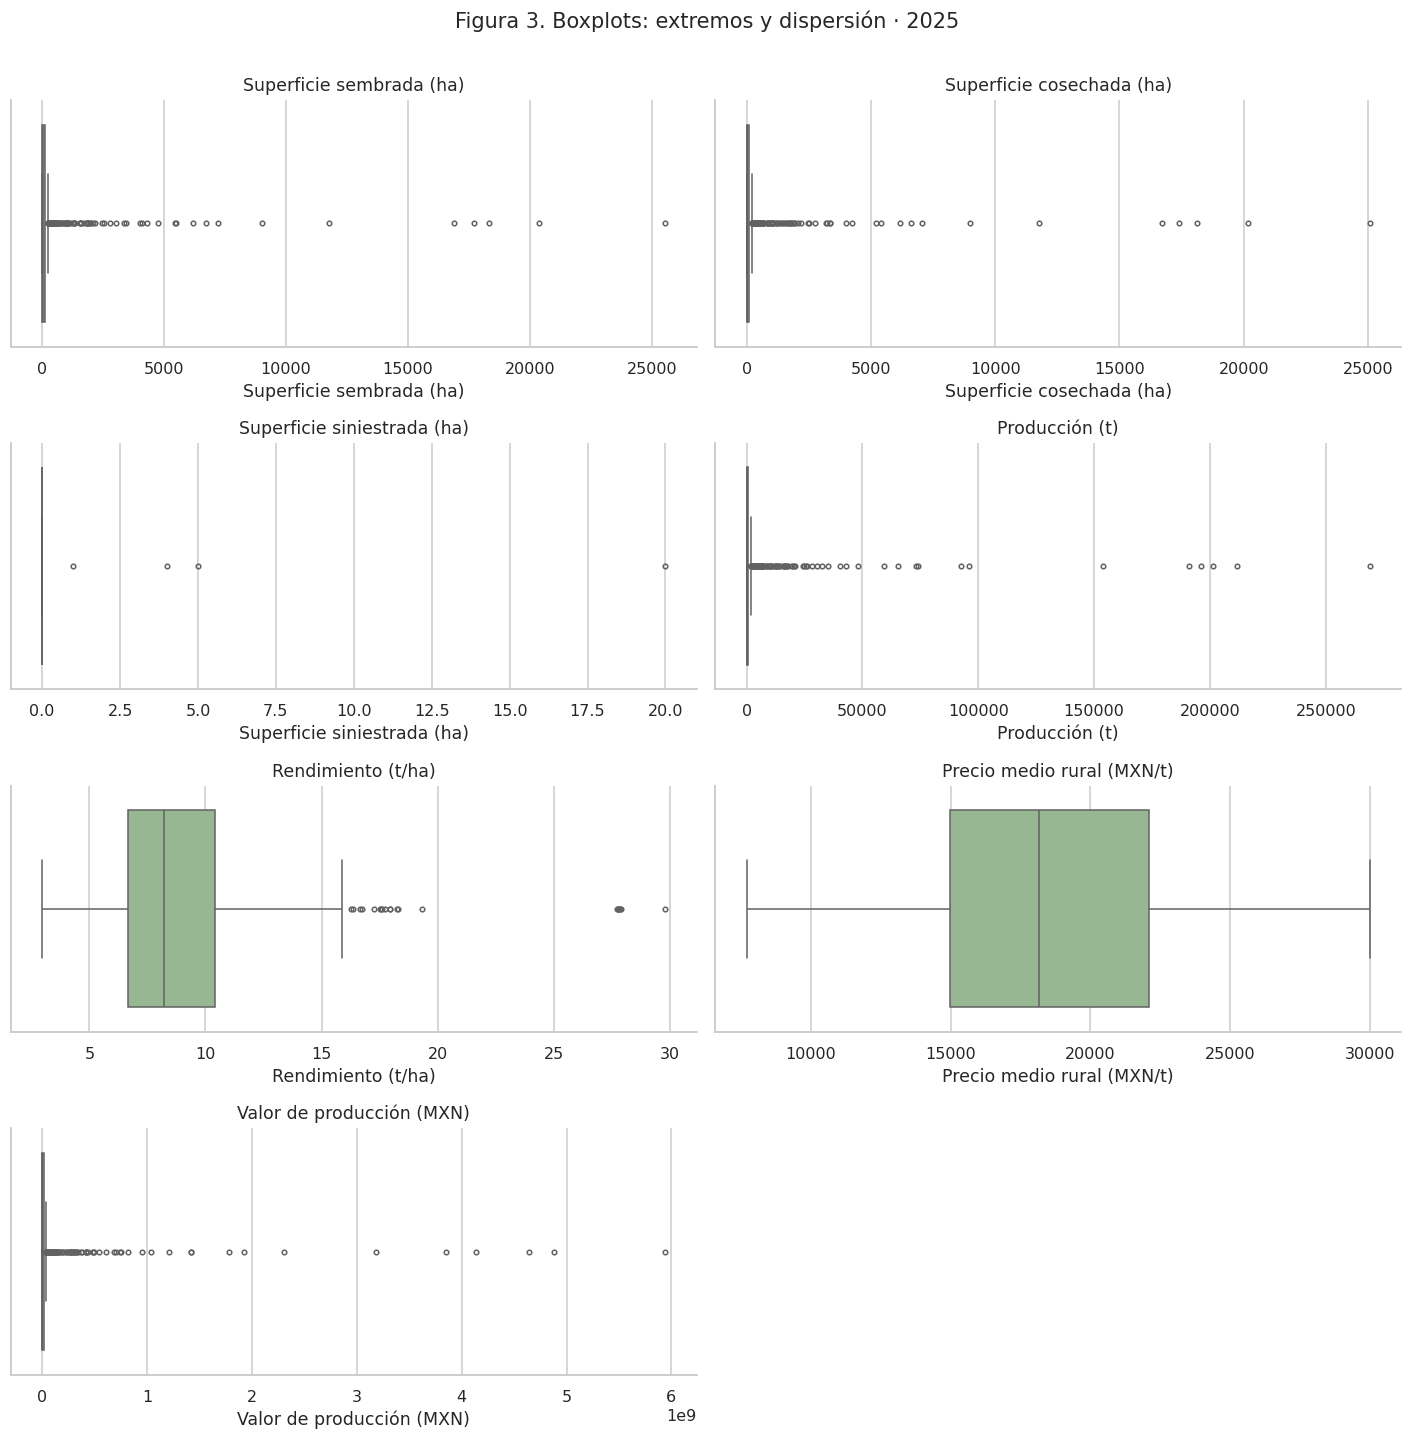

**Interpretación:** comparar la media con la mediana y el percentil 99 permite detectar concentración. Los boxplots señalan candidatos a revisión, no errores demostrados. Un coeficiente de variación >1 o curtosis elevada describe dispersión/colas; por sí solo no demuestra caos determinista, varianza infinita ni una cantidad obligatoria de muestras.

In [6]:
res=actual[N].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T
res['asimetria']=actual[N].skew()
res['curtosis_exceso']=actual[N].kurt()
res['coef_variacion']=actual[N].std().div(actual[N].mean().replace(0,np.nan))
res['desviacion_mayor_media']=actual[N].std()>actual[N].mean()
res['no_aplicables']=actual[N].isna().sum()
tabla(res.reset_index(names='variable'),'08_descriptivos_2025')
labels={'SUPERFICIE_SEMBRADA':'Superficie sembrada (ha)','SUPERFICIE_COSECHADA':'Superficie cosechada (ha)',
'SUPERFICIE_SINIESTRADA':'Superficie siniestrada (ha)','VOLUMEN_PRODUCCION':'Producción (t)',
'RENDIMIENTO':'Rendimiento (t/ha)','PRECIO':'Precio medio rural (MXN/t)','VALOR_PRODUCCION':'Valor de producción (MXN)'}
fig,axs=plt.subplots(4,2,figsize=(13,14))
for ax,c in zip(axs.flat,N):
    sns.histplot(actual[c].dropna(),bins=30,ax=ax,color='#287b61')
    ax.set(xlabel=labels[c],ylabel='Municipios',title=labels[c])
axs.flat[-1].axis('off');fig.suptitle('Figura 2. Distribuciones originales · municipios, 2025',y=1.005)
figura('fig02_histogramas')
fig,axs=plt.subplots(4,2,figsize=(13,13))
for ax,c in zip(axs.flat,N):
    sns.boxplot(x=actual[c].dropna(),ax=ax,color='#91bd8b',fliersize=3)
    ax.set(xlabel=labels[c],title=labels[c])
axs.flat[-1].axis('off');fig.suptitle('Figura 3. Boxplots: extremos y dispersión · 2025',y=1.005)
figura('fig03_boxplots')
nota('**Interpretación:** comparar la media con la mediana y el percentil 99 permite detectar concentración. Los boxplots señalan candidatos a revisión, no errores demostrados. Un coeficiente de variación >1 o curtosis elevada describe dispersión/colas; por sí solo no demuestra caos determinista, varianza infinita ni una cantidad obligatoria de muestras.')

,variable,categorias
0,ENTIDAD,30
1,MUNICIPIO,650
2,CVEGEO,655
3,MODALIDAD,2


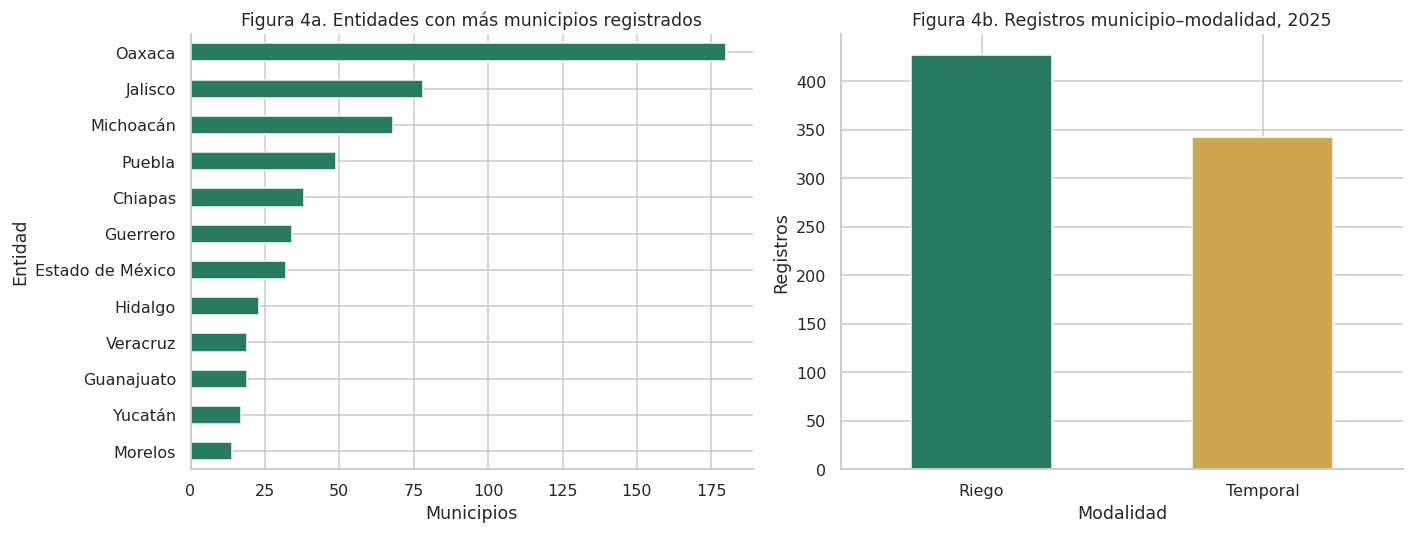

Las barras cuentan registros, no toneladas. Un municipio puede tener riego y temporal, por lo que las frecuencias de modalidades no representan municipios mutuamente excluyentes. Los nombres municipales se acompañan siempre de entidad y CVEGEO para evitar homónimos.

In [7]:
# Categorías: frecuencias, cardinalidad e importancia por volumen.
frecuencias25=[]
for c in ['ENTIDAD','MUNICIPIO','CVEGEO']:
    vc=actual[c].value_counts()
    frecuencias25.extend({'variable':c,'categoria':str(k),'n':int(v),'pct':v/len(actual)*100} for k,v in vc.items())
m25=mod.loc[mod['AÑO'].eq(2025)]
for k,v in m25.MODALIDAD.value_counts().items():
    frecuencias25.append({'variable':'MODALIDAD','categoria':k,'n':int(v),'pct':v/len(m25)*100})
tabla(pd.DataFrame(frecuencias25),'09_frecuencias_2025',False)
card=pd.DataFrame({'variable':['ENTIDAD','MUNICIPIO','CVEGEO','MODALIDAD'],
 'categorias':[actual.ENTIDAD.nunique(),actual.MUNICIPIO.nunique(),actual.CVEGEO.nunique(),m25.MODALIDAD.nunique()]})
tabla(card,'10_cardinalidad')
fig,ax=plt.subplots(1,2,figsize=(13,5))
actual.ENTIDAD.value_counts().head(12).sort_values().plot.barh(ax=ax[0],color='#287b61')
ax[0].set(title='Figura 4a. Entidades con más municipios registrados',xlabel='Municipios',ylabel='Entidad')
m25.MODALIDAD.value_counts().plot.bar(ax=ax[1],color=['#287b61','#cda64f'],rot=0)
ax[1].set(title='Figura 4b. Registros municipio–modalidad, 2025',ylabel='Registros',xlabel='Modalidad')
figura('fig04_categorias')
nota('Las barras cuentan registros, no toneladas. Un municipio puede tener riego y temporal, por lo que las frecuencias de modalidades no representan municipios mutuamente excluyentes. Los nombres municipales se acompañan siempre de entidad y CVEGEO para evitar homónimos.')

### 5.1 Tratamiento de atípicos y sesgo
Se ejecuta la regla descriptiva de Tukey: límites `Q1 − 1.5×IQR` y `Q3 + 1.5×IQR`, por variable en 2025. Cuando IQR=0, la regla se identifica como degenerada y solo sirve como señal; no se usa para eliminar valores. Los extremos productivos se conservan porque son precisamente los nodos relevantes para logística. Se crea `log1p` para magnitudes no negativas y se compara su asimetría. No se aplica Box–Cox indiscriminadamente a ceros.

,variable,Q1,Q3,IQR,regla_degenerada,n_atipicos,pct_validos,asimetria_original,asimetria_log1p
0,SUPERFICIE_SEMBRADA,7.000,99.750,92.750,False,100,15.267,8.714,0.846
1,SUPERFICIE_COSECHADA,6.000,86.250,80.250,False,100,15.267,8.813,0.825
2,SUPERFICIE_SINIESTRADA,0.000,0.000,0.000,True,4,0.611,22.546,16.003
3,VOLUMEN_PRODUCCION,41.875,778.000,736.125,False,105,16.031,8.563,0.461
4,RENDIMIENTO,6.683,10.407,3.724,False,21,3.261,2.200,0.213
5,PRECIO,"14,977.475","22,099.384","7,121.909",False,0,0.000,0.105,-0.545
6,VALOR_PRODUCCION,"715,840.155","15,326,848.615","14,611,008.460",False,101,15.420,8.684,-1.661


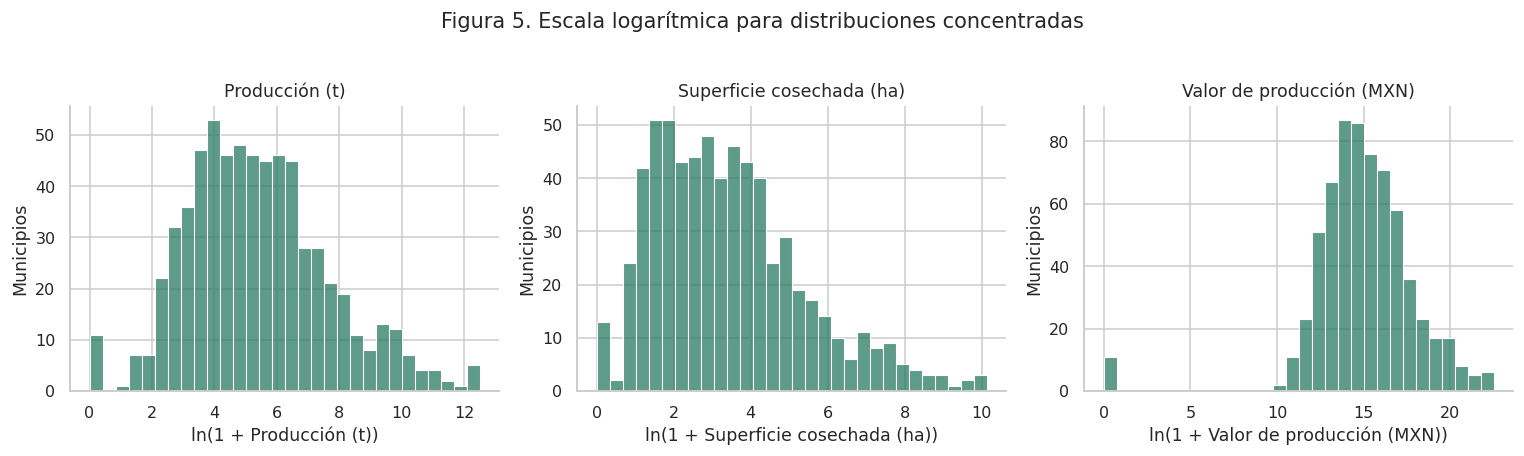

Producción: asimetría original **8.56**; después de log1p **0.46**. Se conservan las toneladas originales para totales y se usa log1p solo para visualización/perfiles. No se garantiza normalidad por transformar.

In [8]:
atipicos=[]
for c in N:
    q1,q3=actual[c].quantile([.25,.75]);iqr=q3-q1
    flag=(actual[c]<q1-1.5*iqr)|(actual[c]>q3+1.5*iqr)
    actual['IQR_'+c]=flag
    atipicos.append({'variable':c,'Q1':q1,'Q3':q3,'IQR':iqr,'regla_degenerada':iqr==0,
      'n_atipicos':int(flag.sum()),'pct_validos':100*flag.sum()/actual[c].notna().sum(),
      'asimetria_original':actual[c].skew(),'asimetria_log1p':np.log1p(actual[c]).skew()})
atip=pd.DataFrame(atipicos);tabla(atip,'11_atipicos_y_transformacion')
for c in N: actual['LOG1P_'+c]=np.log1p(actual[c])
actual['ALGUN_EXTREMO_IQR']=actual[['IQR_'+c for c in N]].any(axis=1)
tabla(actual.loc[actual.ALGUN_EXTREMO_IQR,['CVEGEO','ENTIDAD','MUNICIPIO']+N].sort_values('VOLUMEN_PRODUCCION',ascending=False),'12_municipios_extremos',False)
fig,ax=plt.subplots(1,3,figsize=(14,4))
for a,c in zip(ax,['VOLUMEN_PRODUCCION','SUPERFICIE_COSECHADA','VALOR_PRODUCCION']):
    sns.histplot(actual['LOG1P_'+c],bins=30,ax=a,color='#287b61')
    a.set(xlabel='ln(1 + '+labels[c]+')',ylabel='Municipios',title=labels[c])
fig.suptitle('Figura 5. Escala logarítmica para distribuciones concentradas',y=1.03)
figura('fig05_logaritmos')
nota(f'Producción: asimetría original **{actual.VOLUMEN_PRODUCCION.skew():.2f}**; después de log1p **{actual.LOG1P_VOLUMEN_PRODUCCION.skew():.2f}**. Se conservan las toneladas originales para totales y se usa log1p solo para visualización/perfiles. No se garantiza normalidad por transformar.')

## 6. Relaciones bi/multivariantes y concentración territorial
Se reportan matrices numéricas Pearson y Spearman y ambas representaciones gráficas. Los códigos geográficos no se correlacionan. La superficie siniestrada se omite de la matriz si es constante en este corte; el motivo se muestra, sin ocultarla del diagnóstico univariante.

Las correlaciones son descriptivas y no causales. Producción, superficie y rendimiento tienen una relación aritmética; también valor, volumen y precio. Utilizar todas esas variables contemporáneas para predecir la propia producción podría producir fuga de información.

Variables constantes excluidas de correlación: set()


,variable,SUPERFICIE_SEMBRADA,SUPERFICIE_COSECHADA,SUPERFICIE_SINIESTRADA,VOLUMEN_PRODUCCION,RENDIMIENTO,PRECIO,VALOR_PRODUCCION
0,SUPERFICIE_SEMBRADA,1.000,0.999,-0.011,0.995,0.133,0.103,0.991
1,SUPERFICIE_COSECHADA,0.999,1.000,-0.011,0.997,0.133,0.105,0.994
2,SUPERFICIE_SINIESTRADA,-0.011,-0.011,1.000,-0.011,-0.028,-0.018,-0.011
3,VOLUMEN_PRODUCCION,0.995,0.997,-0.011,1.000,0.146,0.109,0.997
4,RENDIMIENTO,0.133,0.133,-0.028,0.146,1.000,0.222,0.144
5,PRECIO,0.103,0.105,-0.018,0.109,0.222,1.000,0.124
6,VALOR_PRODUCCION,0.991,0.994,-0.011,0.997,0.144,0.124,1.000


,variable,SUPERFICIE_SEMBRADA,SUPERFICIE_COSECHADA,SUPERFICIE_SINIESTRADA,VOLUMEN_PRODUCCION,RENDIMIENTO,PRECIO,VALOR_PRODUCCION
0,SUPERFICIE_SEMBRADA,1.000,0.974,-0.067,0.959,0.424,0.277,0.947
1,SUPERFICIE_COSECHADA,0.974,1.000,-0.110,0.986,0.436,0.266,0.972
2,SUPERFICIE_SINIESTRADA,-0.067,-0.110,1.000,-0.112,-0.041,-0.024,-0.113
3,VOLUMEN_PRODUCCION,0.959,0.986,-0.112,1.000,0.569,0.305,0.990
4,RENDIMIENTO,0.424,0.436,-0.041,0.569,1.000,0.354,0.586
5,PRECIO,0.277,0.266,-0.024,0.305,0.354,1.000,0.431
6,VALOR_PRODUCCION,0.947,0.972,-0.113,0.990,0.586,0.431,1.000


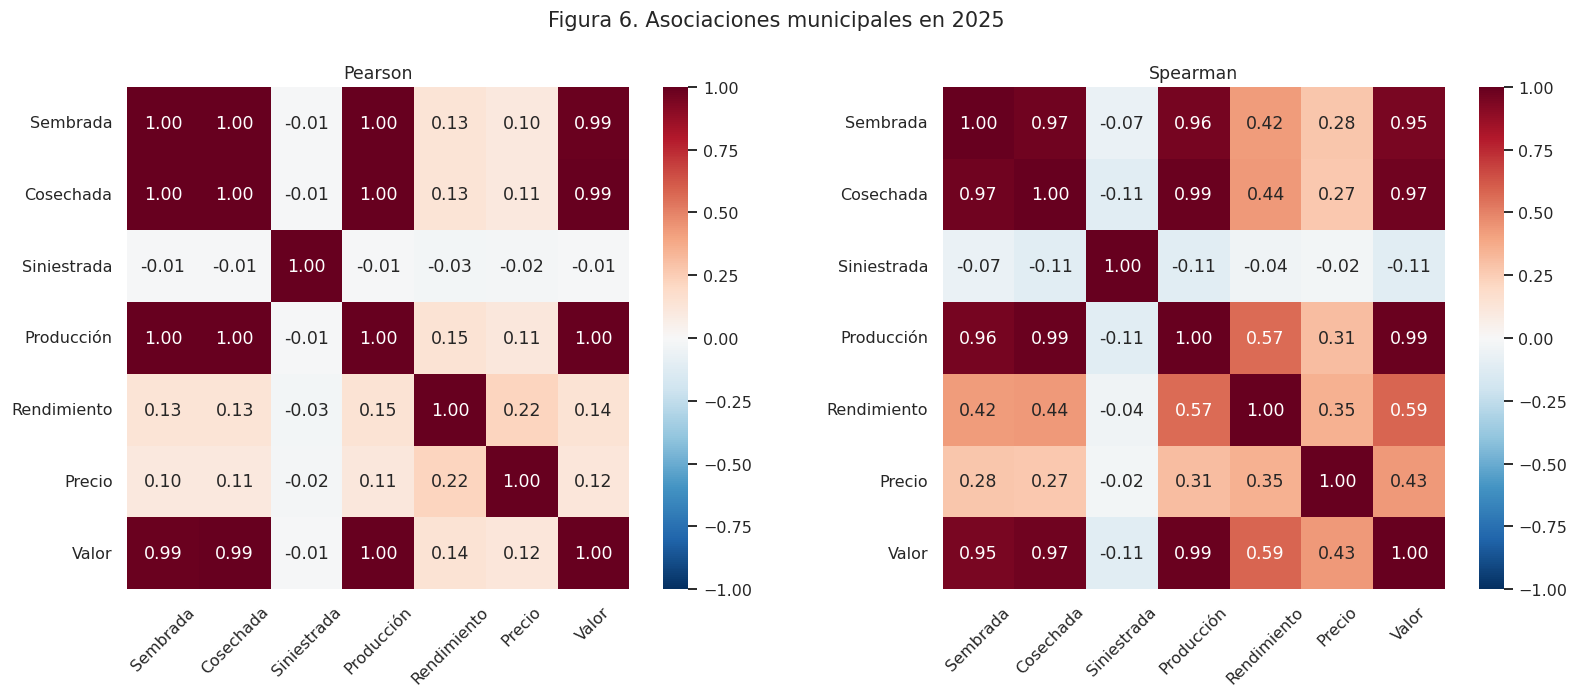

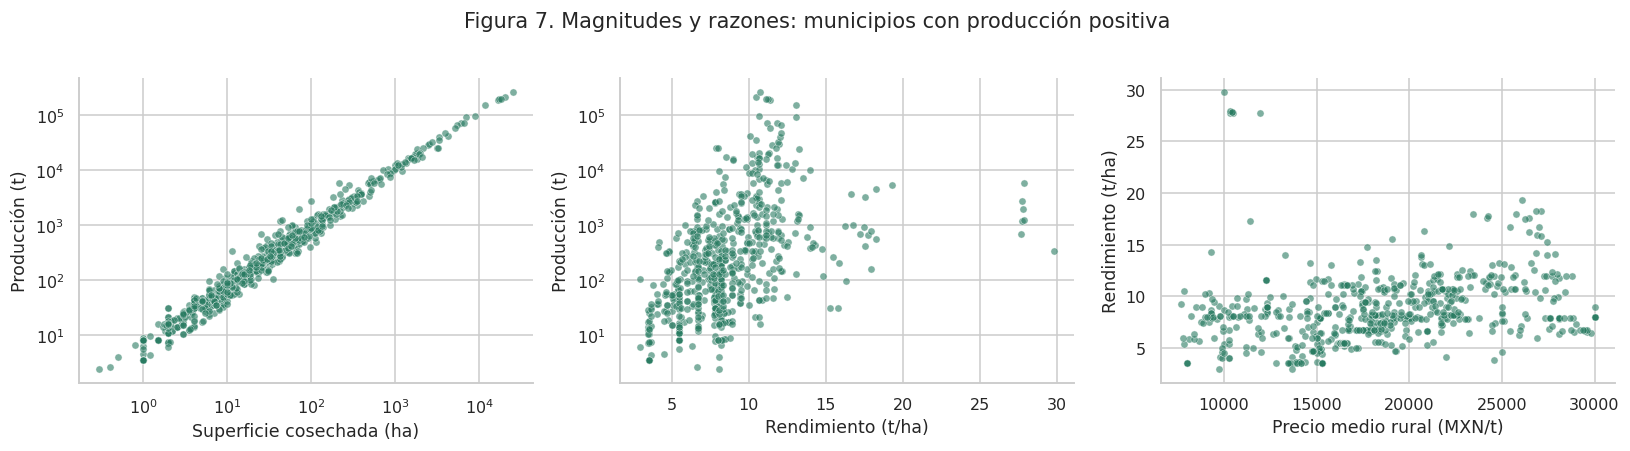

La asociación superficie cosechada–producción es **r=0.997**, frente a **rho=0.986**. La comparación permite distinguir asociación lineal y monotónica; ninguna demuestra el efecto causal de aumentar superficie. El tamaño de los municipios influye en la relación.

In [9]:
corcols=[c for c in N if actual[c].nunique(dropna=True)>1]
print('Variables constantes excluidas de correlación:',set(N)-set(corcols))
pearson=actual[corcols].corr(method='pearson',min_periods=10)
spearman=actual[corcols].corr(method='spearman',min_periods=10)
tabla(pearson.reset_index(names='variable'),'13_correlacion_pearson')
tabla(spearman.reset_index(names='variable'),'14_correlacion_spearman')
conteo=actual[corcols].notna().astype(int).T.dot(actual[corcols].notna().astype(int))
tabla(conteo.reset_index(names='variable'),'15_n_pares_correlacion',False)
short={'SUPERFICIE_SEMBRADA':'Sembrada','SUPERFICIE_COSECHADA':'Cosechada','SUPERFICIE_SINIESTRADA':'Siniestrada','VOLUMEN_PRODUCCION':'Producción','RENDIMIENTO':'Rendimiento','PRECIO':'Precio','VALOR_PRODUCCION':'Valor'}
fig,ax=plt.subplots(1,2,figsize=(15,6))
for a,mat,t in [(ax[0],pearson,'Pearson'),(ax[1],spearman,'Spearman')]:
    sns.heatmap(mat.rename(index=short,columns=short),annot=True,fmt='.2f',vmin=-1,vmax=1,cmap='RdBu_r',ax=a,square=True)
    a.set_title(t);a.tick_params(axis='x',rotation=45)
fig.suptitle('Figura 6. Asociaciones municipales en 2025',y=1.02)
figura('fig06_correlaciones')
fig,ax=plt.subplots(1,3,figsize=(15,4))
pairs=[('SUPERFICIE_COSECHADA','VOLUMEN_PRODUCCION'),('RENDIMIENTO','VOLUMEN_PRODUCCION'),('PRECIO','RENDIMIENTO')]
for a,(x,y) in zip(ax,pairs):
    sns.scatterplot(data=activos,x=x,y=y,alpha=.6,s=22,ax=a,color='#287b61')
    if x=='SUPERFICIE_COSECHADA':a.set_xscale('log')
    if y=='VOLUMEN_PRODUCCION':a.set_yscale('log')
    a.set(xlabel=labels[x],ylabel=labels[y])
fig.suptitle('Figura 7. Magnitudes y razones: municipios con producción positiva',y=1.02)
figura('fig07_dispersion')
nota(f'La asociación superficie cosechada–producción es **r={pearson.loc["SUPERFICIE_COSECHADA","VOLUMEN_PRODUCCION"]:.3f}**, frente a **rho={spearman.loc["SUPERFICIE_COSECHADA","VOLUMEN_PRODUCCION"]:.3f}**. La comparación permite distinguir asociación lineal y monotónica; ninguna demuestra el efecto causal de aumentar superficie. El tamaño de los municipios influye en la relación.')

,ENTIDAD,SUPERFICIE_SEMBRADA,SUPERFICIE_COSECHADA,SUPERFICIE_SINIESTRADA,VOLUMEN_PRODUCCION,VALOR_PRODUCCION,participacion_pct
0,Michoacán,"183,711.000","180,998.000",4.000,"2,029,668.220","44,132,468,811.730",72.683
1,Jalisco,"31,628.870","29,073.640",0.000,"350,848.220","8,567,187,679.140",12.564
2,Estado de México,"12,958.510","12,209.960",0.000,"132,227.580","2,441,463,423.660",4.735
3,Nayarit,"12,823.800","8,902.800",0.000,"73,685.240","710,866,312.750",2.639
4,Morelos,"6,018.000","5,909.000",0.000,"52,415.070","1,137,190,986.070",1.877
5,Guerrero,"3,422.080","3,247.060",0.000,"23,914.970","295,720,636.540",0.856
6,Puebla,"3,577.650","2,841.650",0.000,"22,503.730","387,902,582.140",0.806
7,Oaxaca,"3,707.530","3,235.870",0.000,"22,021.250","426,267,233.370",0.789
8,Chiapas,"3,376.210","2,946.060",0.000,"18,855.250","455,117,223.440",0.675
9,Yucatán,645.180,634.180,0.000,"15,571.930","163,482,376.390",0.558


,CVEGEO,ENTIDAD,MUNICIPIO,VOLUMEN_PRODUCCION,RENDIMIENTO,PRECIO,participacion_pct,acumulado_pct
11304,16083,Michoacán,Tancítaro,"268,975.900",10.727,"22,096.676",9.632,9.632
11263,16009,Michoacán,Ario,"211,762.700",10.497,"21,916.160",7.583,17.215
11320,16102,Michoacán,Uruapan,"201,170.380",11.113,"24,258.511",7.204,24.419
11303,16082,Michoacán,Tacámbaro,"196,028.400",11.257,"19,668.771",7.020,31.439
11301,16079,Michoacán,Salvador Escalante,"190,839.700",11.420,"21,668.303",6.834,38.273
11294,16068,Michoacán,Peribán,"153,789.170",13.087,"20,701.032",5.507,43.781
11287,16058,Michoacán,Nuevo Parangaricutiro,"95,888.600",10.664,"24,088.100",3.434,47.214
11299,16075,Michoacán,Los Reyes,"92,452.120",13.064,"20,816.726",3.311,50.525
11315,16097,Michoacán,Turicato,"73,975.780",11.186,"19,177.606",2.649,53.174
11166,14023,Jalisco,Zapotlán el Grande,"73,229.500",11.840,"24,376.061",2.622,55.797


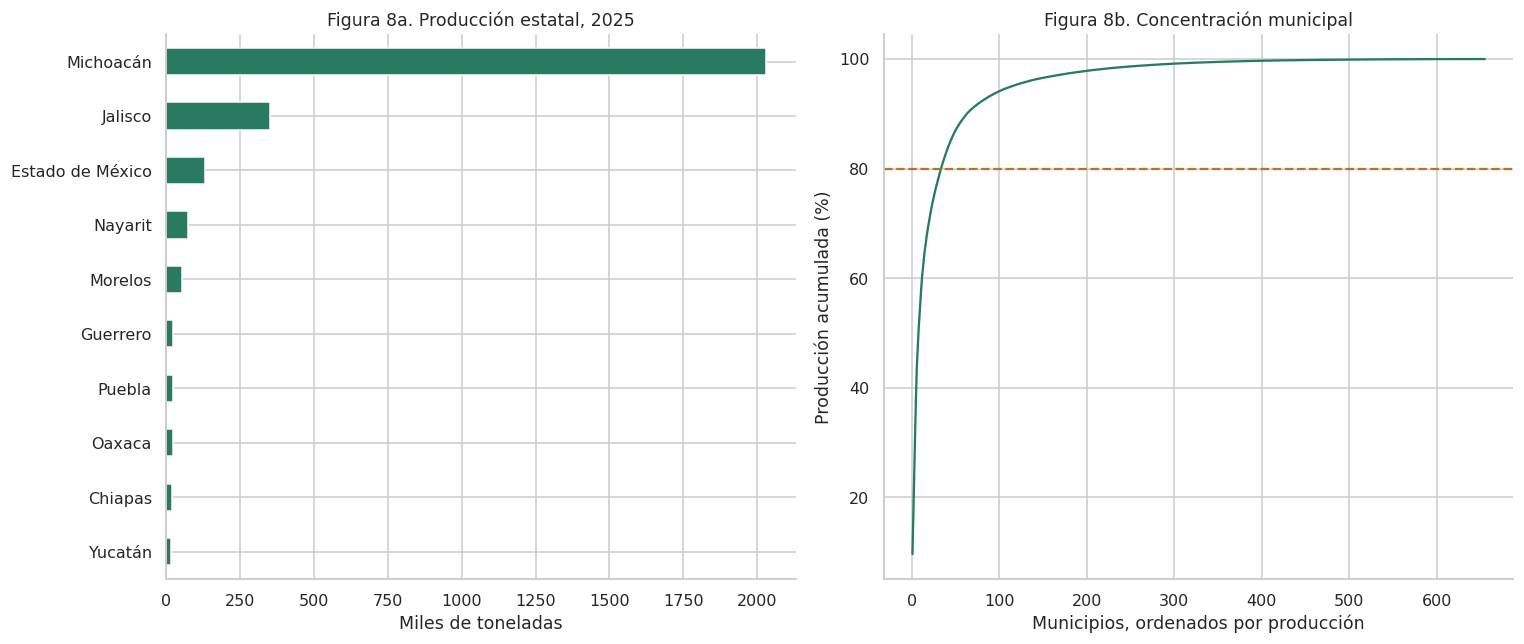

**Implicación logística:** 34 municipios reúnen al menos 80% del volumen 2025. Michoacán aporta 72.68% y los diez principales municipios 55.80%. Esto sirve para priorizar dónde recabar datos de acopio y transporte, pero no prueba la ubicación óptima de un almacén.

In [10]:
est=actual.groupby('ENTIDAD')[A].sum().sort_values('VOLUMEN_PRODUCCION',ascending=False)
est['participacion_pct']=100*est.VOLUMEN_PRODUCCION/est.VOLUMEN_PRODUCCION.sum()
ranking=actual[['CVEGEO','ENTIDAD','MUNICIPIO','VOLUMEN_PRODUCCION','RENDIMIENTO','PRECIO']].sort_values('VOLUMEN_PRODUCCION',ascending=False).copy()
ranking['participacion_pct']=ranking.VOLUMEN_PRODUCCION/ranking.VOLUMEN_PRODUCCION.sum()*100
ranking['acumulado_pct']=ranking.participacion_pct.cumsum()
tabla(est.reset_index(),'16_produccion_estatal')
tabla(ranking,'17_ranking_municipal',False);display(ranking.head(15))
fig,ax=plt.subplots(1,2,figsize=(14,6))
est.head(10).VOLUMEN_PRODUCCION.div(1000).sort_values().plot.barh(ax=ax[0],color='#287b61')
ax[0].set(xlabel='Miles de toneladas',ylabel='',title='Figura 8a. Producción estatal, 2025')
ax[1].plot(np.arange(1,len(ranking)+1),ranking.acumulado_pct,color='#287b61')
ax[1].axhline(80,ls='--',color='#b57527');ax[1].set(xlabel='Municipios, ordenados por producción',ylabel='Producción acumulada (%)',title='Figura 8b. Concentración municipal')
figura('fig08_concentracion')
n80=int(np.searchsorted(ranking.acumulado_pct.to_numpy(),80)+1)
nota(f'**Implicación logística:** {n80} municipios reúnen al menos 80% del volumen 2025. Michoacán aporta {est.loc["Michoacán","participacion_pct"]:.2f}% y los diez principales municipios {ranking.head(10).participacion_pct.sum():.2f}%. Esto sirve para priorizar dónde recabar datos de acopio y transporte, pero no prueba la ubicación óptima de un almacén.')

,MODALIDAD,registros,toneladas,cosechada_ha,valor_mxn,mediana_rendimiento,rendimiento_ponderado,precio_ponderado
0,Riego,427,"1,286,473.140","110,014.450","28,123,414,547.320",8.930,11.694,"21,860.864"
1,Temporal,343,"1,506,007.910","145,645.960","31,466,248,431.560",7.761,10.340,"20,893.814"


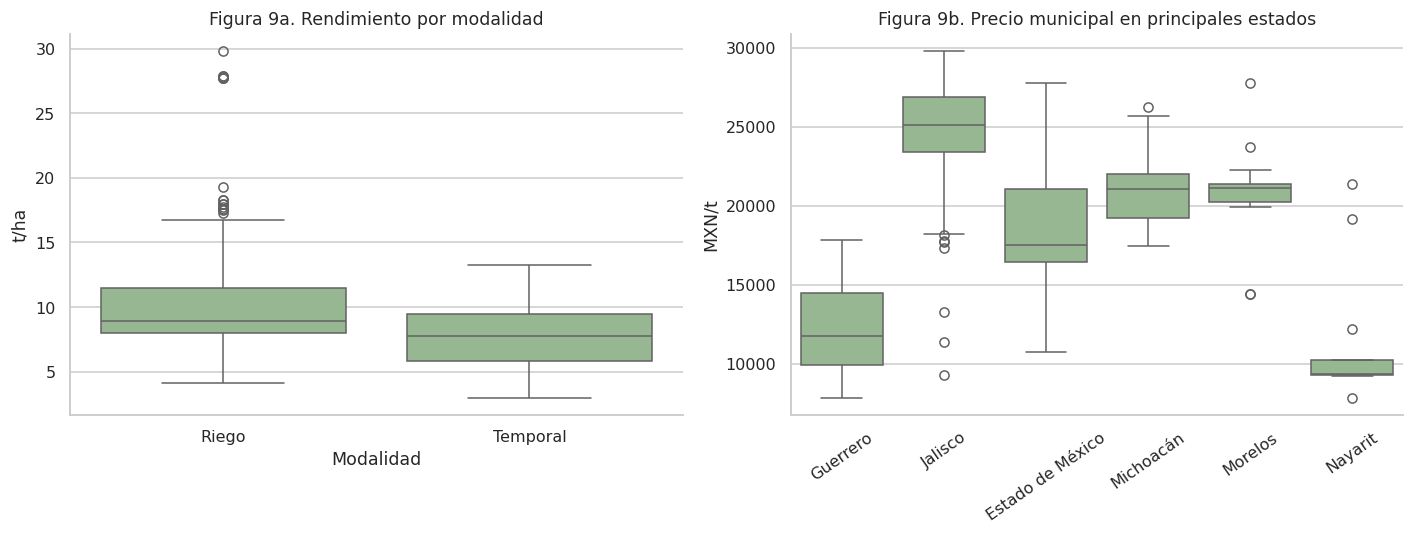

La mediana describe un municipio–modalidad típico; el rendimiento ponderado describe producción total por hectárea cosechada. Las diferencias observadas entre riego y temporal no aíslan clima, variedad, escala ni selección territorial: no permiten atribuir causalidad a la modalidad.

In [11]:
por_modalidad=m25.groupby('MODALIDAD').agg(registros=('CVEGEO','size'),toneladas=('VOLUMEN_PRODUCCION','sum'),
 cosechada_ha=('SUPERFICIE_COSECHADA','sum'),valor_mxn=('VALOR_PRODUCCION','sum'),
 mediana_rendimiento=('RENDIMIENTO','median'))
por_modalidad['rendimiento_ponderado']=por_modalidad.toneladas/por_modalidad.cosechada_ha
por_modalidad['precio_ponderado']=por_modalidad.valor_mxn/por_modalidad.toneladas
tabla(por_modalidad.reset_index(),'18_modalidad_hidrica')
fig,ax=plt.subplots(1,2,figsize=(13,5))
sns.boxplot(data=m25,x='MODALIDAD',y='RENDIMIENTO',ax=ax[0],color='#91bd8b')
ax[0].set(title='Figura 9a. Rendimiento por modalidad',ylabel='t/ha',xlabel='Modalidad')
topstates=est.head(6).index
sns.boxplot(data=actual[actual.ENTIDAD.isin(topstates)],x='ENTIDAD',y='PRECIO',ax=ax[1],color='#91bd8b')
ax[1].tick_params(axis='x',rotation=35);ax[1].set(title='Figura 9b. Precio municipal en principales estados',ylabel='MXN/t',xlabel='')
figura('fig09_comparacion_categorias')
nota('La mediana describe un municipio–modalidad típico; el rendimiento ponderado describe producción total por hectárea cosechada. Las diferencias observadas entre riego y temporal no aíslan clima, variedad, escala ni selección territorial: no permiten atribuir causalidad a la modalidad.')

## 7. Evolución temporal y cobertura
La serie es anual: permite estudiar cambios de largo plazo, **no estacionalidad mensual**. La ausencia de un municipio–año puede corresponder a falta de registro o cambio territorial; no se convierte automáticamente en producción cero. Los códigos geográficos no garantizan límites territoriales constantes durante 22 años.

,AÑO,SUPERFICIE_SEMBRADA,SUPERFICIE_COSECHADA,SUPERFICIE_SINIESTRADA,VOLUMEN_PRODUCCION,VALOR_PRODUCCION,RENDIMIENTO,PRECIO,variacion_anual_pct,municipios_registrados
0,2003,"97,786.800","95,399.480",0.000,"905,041.150","5,373,581,667.750",9.487,"5,937.389",NaN,425.000
1,2004,"101,881.820","100,126.620",0.000,"987,323.340","6,085,761,266.870",9.861,"6,163.899",9.092,423.000
2,2005,"112,250.590","103,119.100",0.000,"1,021,515.460","7,617,150,417.630",9.906,"7,456.716",3.463,415.000
3,2006,"114,841.790","105,477.260",0.000,"1,134,249.590","9,122,963,597.300",10.753,"8,043.171",11.036,425.000
4,2007,"117,311.760","110,377.320",0.000,"1,142,892.420","12,019,378,281.100",10.354,"10,516.631",0.762,433.000
5,2008,"122,348.940","112,478.840",0.000,"1,162,428.920","12,459,370,622.860",10.335,"10,718.394",1.709,439.000
6,2009,"129,354.310","121,490.880",0.000,"1,230,972.610","15,073,316,456.470",10.132,"12,245.046",5.897,455.000
7,2010,"134,322.120","123,403.690",0.000,"1,107,135.160","14,165,758,093.970",8.972,"12,794.967",-10.060,458.000
8,2011,"142,146.100","126,597.890",0.000,"1,264,141.460","18,136,404,248.990",9.985,"14,346.815",14.181,488.000
9,2012,"151,022.650","130,307.990",0.000,"1,316,104.020","16,608,146,755.350",10.100,"12,619.175",4.111,498.000


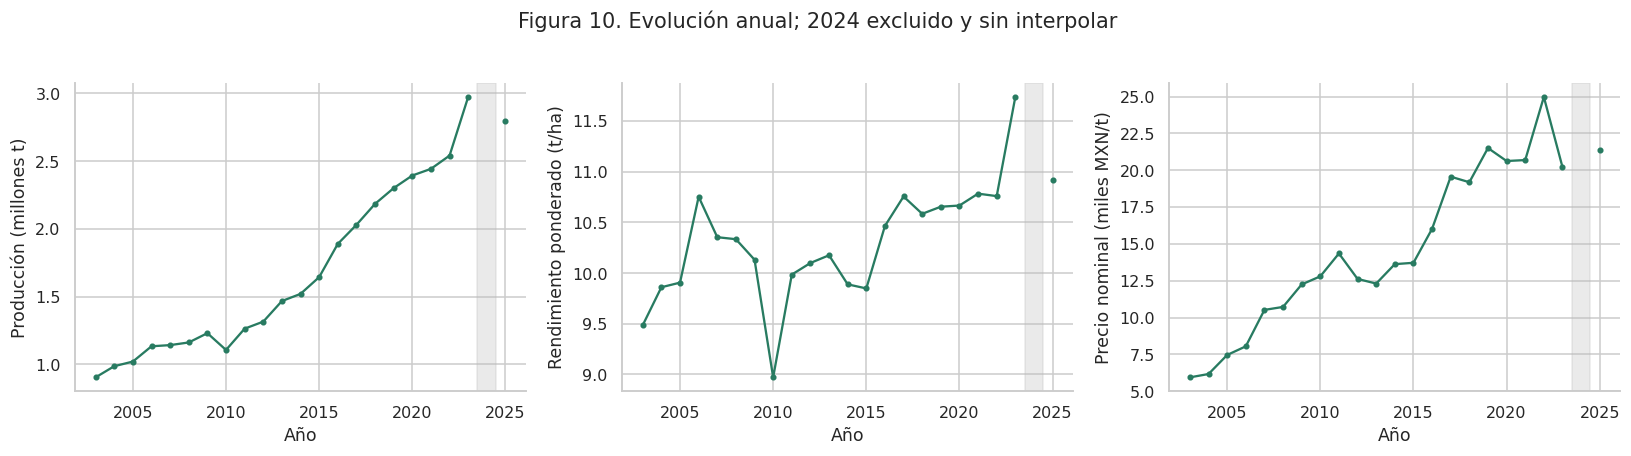

Entre 2003 y 2025 la producción registrada cambió **208.55%**; entre 2023 y 2025, **-6.08%** (cambio de DOS años). No se calcula variación 2025/2024 por la cuarentena. Hay **272** municipios con registros en los 22 años elegibles. El crecimiento de cobertura y cambios territoriales limitan las comparaciones locales; los precios son nominales, no poder adquisitivo real.

In [12]:
anual=mun.groupby('AÑO')[A].sum().reindex(range(2003,2026))
anual['RENDIMIENTO']=anual.VOLUMEN_PRODUCCION/anual.SUPERFICIE_COSECHADA
anual['PRECIO']=anual.VALOR_PRODUCCION/anual.VOLUMEN_PRODUCCION
anual['variacion_anual_pct']=anual.VOLUMEN_PRODUCCION.pct_change(fill_method=None)*100
anual['municipios_registrados']=mun.groupby('AÑO').CVEGEO.nunique()
tabla(anual.reset_index(),'19_evolucion_anual')
fig,ax=plt.subplots(1,3,figsize=(15,4))
for a,c,esc,t in zip(ax,['VOLUMEN_PRODUCCION','RENDIMIENTO','PRECIO'],[1e6,1,1000],['Producción (millones t)','Rendimiento ponderado (t/ha)','Precio nominal (miles MXN/t)']):
    a.plot(anual.index,anual[c]/esc,marker='o',ms=3,color='#287b61')
    a.axvspan(2023.5,2024.5,color='#bbbbbb',alpha=.3);a.set(xlabel='Año',ylabel=t)
fig.suptitle('Figura 10. Evolución anual; 2024 excluido y sin interpolar',y=1.03)
figura('fig10_tendencia')
cob=mun.pivot_table(index='CVEGEO',columns='AÑO',values='VOLUMEN_PRODUCCION',aggfunc='size').reindex(columns=range(2003,2026))
cobertura=pd.DataFrame({'CVEGEO':cob.index,'anios_registrados':cob.notna().sum(axis=1).values})
tabla(cobertura,'20_cobertura_panel',False)
crecimiento=(anual.loc[2025,'VOLUMEN_PRODUCCION']/anual.loc[2003,'VOLUMEN_PRODUCCION']-1)*100
cambio23=(anual.loc[2025,'VOLUMEN_PRODUCCION']/anual.loc[2023,'VOLUMEN_PRODUCCION']-1)*100
nota(f'Entre 2003 y 2025 la producción registrada cambió **{crecimiento:.2f}%**; entre 2023 y 2025, **{cambio23:.2f}%** (cambio de DOS años). No se calcula variación 2025/2024 por la cuarentena. Hay **{int(cobertura.anios_registrados.eq(22).sum())}** municipios con registros en los 22 años elegibles. El crecimiento de cobertura y cambios territoriales limitan las comparaciones locales; los precios son nominales, no poder adquisitivo real.')

## 8. Alta cardinalidad, selección de variables y memoria temporal
**Alta cardinalidad:** se conserva CVEGEO para integración geográfica, pero no se trata como número explicativo ni se generan cientos de dummies de municipio. Para gráficas se agrupan estados fuera del top 5 en “Otros”; la agrupación es descriptiva de 2025, no una transformación entrenada para predecir el futuro. Se mantiene el detalle en los archivos limpios.

**Reducción:** cultivo, unidad y ciclo son constantes; claves/nombres administrativos redundantes se excluyen del conjunto numérico. Para perfiles se seleccionan escala productiva (`log1p` de toneladas), rendimiento y precio. No se añaden simultáneamente valor, superficies y sus razones sin revisar redundancia. No se elimina una variable solo por correlación baja ni se necesita PCA para cumplir la rúbrica.

**Si posteriormente se pronostica producción:** solo se podrán usar variables conocidas antes del horizonte. El rendimiento, valor y precio contemporáneos de cosecha no son predictores automáticamente disponibles. Los rezagos se calculan por año y municipio después de completar el calendario; un salto de dos años nunca se etiqueta Lag1.

Filas con objetivo y lag1 observados: 10143


,GRUPO_ENTIDAD,municipios,produccion_t
0,Estado de México,32,"132,227.580"
1,Jalisco,78,"350,848.220"
2,Michoacán,68,"2,029,668.220"
3,Morelos,14,"52,415.070"
4,Nayarit,13,"73,685.240"
5,Otros,450,"153,636.720"


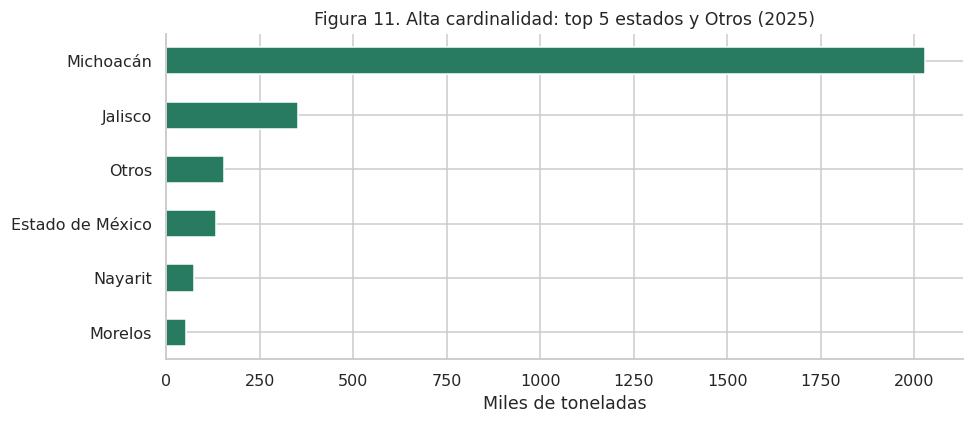

,CVEGEO,AÑO,produccion_t,lag1_t,lag2_t,lag3_t,media_previa3_t
7445,16083,2019,"226,710.000","237,435.000","218,973.700","224,142.400","226,850.367"
7446,16083,2020,"225,420.400","226,710.000","237,435.000","218,973.700","227,706.233"
7447,16083,2021,"227,677.000","225,420.400","226,710.000","237,435.000","229,855.133"
7448,16083,2022,"231,517.000","227,677.000","225,420.400","226,710.000","226,602.467"
7449,16083,2023,"303,620.000","231,517.000","227,677.000","225,420.400","228,204.800"
7451,16083,2025,"268,975.900",NaN,"303,620.000","231,517.000",NaN


2025 tiene Lag1 ausente porque 2024 está separado. Lag2 sí puede contener 2023. No se hace backfill ni se rellena desde años futuros. Este anexo demuestra memoria temporal; no entrena un modelo ni valida capacidad predictiva.

In [13]:
actual['GRUPO_ENTIDAD']=actual.ENTIDAD.where(actual.ENTIDAD.isin(est.head(5).index),'Otros')
agrup=actual.groupby('GRUPO_ENTIDAD').agg(municipios=('CVEGEO','size'),produccion_t=('VOLUMEN_PRODUCCION','sum')).reset_index()
tabla(agrup,'21_agrupacion_cardinalidad')
fig,ax=plt.subplots(figsize=(9,4))
agrup.sort_values('produccion_t').set_index('GRUPO_ENTIDAD').produccion_t.div(1000).plot.barh(ax=ax,color='#287b61')
ax.set(xlabel='Miles de toneladas',ylabel='',title='Figura 11. Alta cardinalidad: top 5 estados y Otros (2025)')
figura('fig11_cardinalidad')

# Calendario completo; no se imputan observaciones ausentes.
series=mun.set_index(['CVEGEO','AÑO']).VOLUMEN_PRODUCCION.unstack('AÑO').reindex(columns=range(2003,2026))
registros=[]
for geo,row in series.iterrows():
    s=row.astype(float)
    temp=pd.DataFrame({'CVEGEO':geo,'AÑO':s.index,'produccion_t':s.values,
      'lag1_t':s.shift(1).values,'lag2_t':s.shift(2).values,'lag3_t':s.shift(3).values,
      'media_previa3_t':s.shift(1).rolling(3,min_periods=3).mean().values})
    registros.append(temp)
lags=pd.concat(registros,ignore_index=True)
lags=lags.loc[lags.produccion_t.notna()].copy()
assert lags.loc[lags['AÑO'].eq(2025),'lag1_t'].isna().all()
lags.to_csv(PRO/'rezagos_calendario.csv',index=False,encoding='utf-8-sig')
display(lags.loc[lags.CVEGEO.eq(ranking.iloc[0].CVEGEO)].tail(6))
print('Filas con objetivo y lag1 observados:', int(lags[['produccion_t','lag1_t']].notna().all(axis=1).sum()))
nota('2025 tiene Lag1 ausente porque 2024 está separado. Lag2 sí puede contener 2023. No se hace backfill ni se rellena desde años futuros. Este anexo demuestra memoria temporal; no entrena un modelo ni valida capacidad predictiva.')

## 9. Exploración no supervisada de perfiles municipales
Como respuesta exploratoria a la retroalimentación, se agrupan municipios productores de 2025 mediante K-means sobre log-producción, rendimiento y precio, escalados con mediana/IQR. Se comparan k=2,3,4,5 con silueta. Esta es una **segmentación descriptiva** del corte disponible: los grupos no son clases verdaderas ni anomalías confirmadas. Su estabilidad temporal y utilidad operativa requieren validación posterior.

,k,silueta
0,2,0.381
1,3,0.279
2,4,0.294
3,5,0.298


,grupo,municipios,produccion_total_t,mediana_produccion_t,mediana_rendimiento,mediana_precio
0,1,200,"2,693,302.250","1,771.340",11.132,"21,539.300"
1,2,444,"99,178.800",77.765,7.502,"16,621.845"


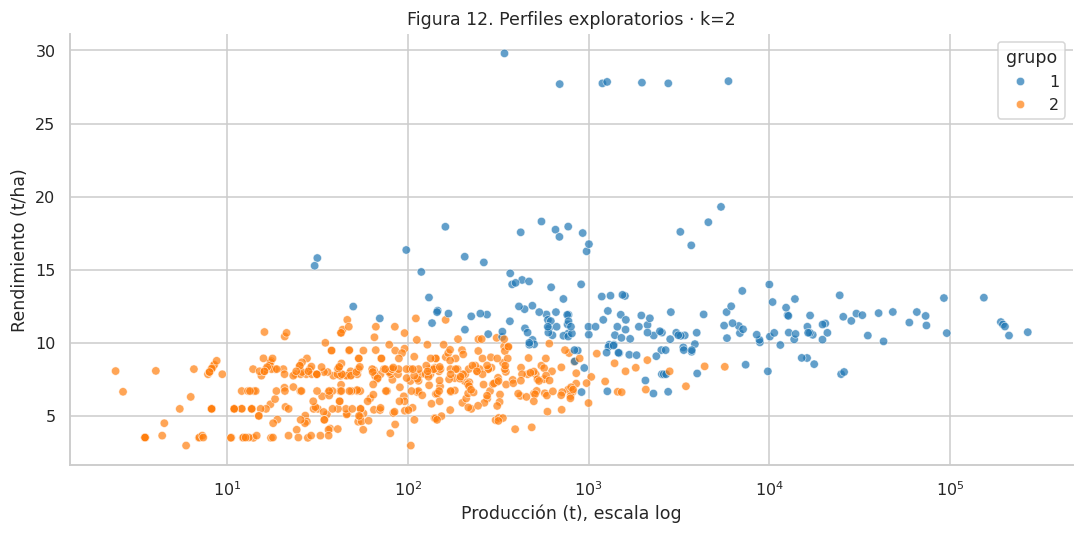

Se eligió k=2 por la mayor silueta entre los candidatos, no por una validación externa. Los perfiles ayudan a seleccionar municipios de distinta escala/rendimiento para levantamiento logístico. Los extremos IQR del §5 siguen siendo señales de revisión independientes de estos grupos.

In [14]:
perfiles=activos[['CVEGEO','ENTIDAD','MUNICIPIO','VOLUMEN_PRODUCCION','RENDIMIENTO','PRECIO']].dropna().copy()
X=perfiles[['VOLUMEN_PRODUCCION','RENDIMIENTO','PRECIO']].copy()
X['VOLUMEN_PRODUCCION']=np.log1p(X.VOLUMEN_PRODUCCION)
Xz=RobustScaler().fit_transform(X)
comparacion=[];modelos={}
for k in [2,3,4,5]:
    km=KMeans(n_clusters=k,random_state=42,n_init=20).fit(Xz)
    modelos[k]=km
    comparacion.append({'k':k,'silueta':silhouette_score(Xz,km.labels_)})
comparacion=pd.DataFrame(comparacion);tabla(comparacion,'22_silueta_clusters')
kbest=int(comparacion.loc[comparacion.silueta.idxmax(),'k'])
perfiles['grupo']=modelos[kbest].labels_+1
perfil=perfiles.groupby('grupo').agg(municipios=('CVEGEO','size'),produccion_total_t=('VOLUMEN_PRODUCCION','sum'),
 mediana_produccion_t=('VOLUMEN_PRODUCCION','median'),mediana_rendimiento=('RENDIMIENTO','median'),mediana_precio=('PRECIO','median')).reset_index()
tabla(perfil,'23_perfiles_municipales')
perfiles.to_csv(PRO/'perfiles_2025.csv',index=False,encoding='utf-8-sig')
fig,ax=plt.subplots(figsize=(10,5))
sns.scatterplot(data=perfiles,x='VOLUMEN_PRODUCCION',y='RENDIMIENTO',hue='grupo',palette='tab10',s=30,alpha=.7,ax=ax)
ax.set_xscale('log');ax.set(xlabel='Producción (t), escala log',ylabel='Rendimiento (t/ha)',title=f'Figura 12. Perfiles exploratorios · k={kbest}')
figura('fig12_perfiles')
nota(f'Se eligió k={kbest} por la mayor silueta entre los candidatos, no por una validación externa. Los perfiles ayudan a seleccionar municipios de distinta escala/rendimiento para levantamiento logístico. Los extremos IQR del §5 siguen siendo señales de revisión independientes de estos grupos.')

## 10. Conclusiones con evidencia y decisiones
Las siguientes cifras se generan desde las tablas anteriores para evitar discrepancias entre texto y resultados.

In [15]:
principal=ranking.iloc[0]
r_vol=atip.set_index('variable').loc['VOLUMEN_PRODUCCION']
texto=f"""
1. **Cobertura y calidad.** La copia contiene {len(raw):,} registros y 24 columnas originales. El panel limpio conserva {len(mun):,} municipio–año en 22 años elegibles (2003–2023 y 2025). En 2025 existen {len(actual):,} municipios registrados, {len(activos):,} con producción positiva. Los años 1980–2002 no son comparables a nivel municipal y 2024 permanece en cuarentena por 137 repeticiones adicionales de la clave administrativa disponible.
2. **Faltantes.** La ausencia histórica de municipio es estructural. En los registros elegibles hay {int(d.SIN_COSECHA.sum()):,} casos sin superficie cosechada, para los cuales rendimiento y precio quedan como no aplicables; no se asigna una mediana artificial. No quedan razones ausentes entre registros con cosecha positiva. La ausencia de municipio–año no se considera producción cero.
3. **Oferta concentrada.** La producción agregada de 2025 es **{actual.VOLUMEN_PRODUCCION.sum():,.2f} t**. Michoacán representa **{est.loc['Michoacán','participacion_pct']:.2f}%**. Los diez municipios principales acumulan **{ranking.head(10).participacion_pct.sum():.2f}%** y {n80} municipios alcanzan 80%. {principal.MUNICIPIO}, {principal.ENTIDAD}, encabeza el ranking con **{principal.VOLUMEN_PRODUCCION:,.2f} t**. Estos datos priorizan candidatos para recopilar información de acopio y distribución.
4. **Sesgo y extremos.** Producción tiene media **{actual.VOLUMEN_PRODUCCION.mean():,.2f} t** frente a mediana **{actual.VOLUMEN_PRODUCCION.median():,.2f} t**. La regla IQR marca **{int(r_vol.n_atipicos)}** municipios ({r_vol.pct_validos:.2f}% de los válidos); se conservan. Log1p reduce la asimetría de **{r_vol.asimetria_original:.2f}** a **{r_vol.asimetria_log1p:.2f}**. Los indicadores no prueban caos ni varianza infinita.
5. **Relaciones.** Superficie cosechada y producción presentan Pearson **{pearson.loc['SUPERFICIE_COSECHADA','VOLUMEN_PRODUCCION']:.3f}** y Spearman **{spearman.loc['SUPERFICIE_COSECHADA','VOLUMEN_PRODUCCION']:.3f}**. Es una asociación coherente con su relación aritmética y la escala productiva, no causalidad. Se evita usar cantidades derivadas del objetivo como si fueran predictores previos.
6. **Categorías y dimensionalidad.** El corte 2025 tiene {actual.CVEGEO.nunique()} claves municipales y {actual.ENTIDAD.nunique()} entidades. Se conserva la clave para integración; para gráficas se usan 6 grupos territoriales (top 5 y Otros). Los perfiles omiten identificadores y constantes. Las diferencias de rendimiento por modalidad se reportan con medianas y ponderaciones; no prueban un efecto causal del riego.
7. **Tiempo.** El cambio de producción 2003–2025 es **{crecimiento:.2f}%**; de 2023 a 2025, **{cambio23:.2f}%**. No se interpreta estacionalidad mensual desde datos anuales, ni se inventa 2024. Precios nominales requieren deflactor antes de interpretar variaciones reales. Los rezagos respetan años calendario y municipio.
8. **Segmentación.** La exploración selecciona **{kbest} grupos** por silueta entre k=2–5. Se trata de perfiles descriptivos para orientar levantamiento de información, no de clases validadas ni detección probada de anomalías operativas.
9. **Aplicación logística y límite.** Se obtiene una base territorial reproducible para seleccionar zonas de estudio. No hay observaciones de centros de acopio, demanda de destino, distancias de carretera, capacidad/carga de camiones, litros ni emisiones. Por tanto, no se afirma una ruta óptima, ahorro de combustible o reducción de CO₂. Un CADER es una unidad administrativa y no se sustituye por un centro de acopio.
10. **Siguiente avance.** Aclarar 2024 con el archivo oficial; verificar vigencia de límites municipales; integrar centros de acopio/destinos georreferenciados y rutas de INEGI; registrar capacidades, viajes y consumo. Definir con el sponsor la función objetivo (costo, distancia o emisiones) y restricciones antes de optimizar. La base histórica no mide oferta diaria disponible para embarque.
"""
nota(texto)
(OUT/'conclusiones.md').write_text(texto,encoding='utf-8')

Out[0]: 3398



1. **Cobertura y calidad.** La copia contiene 15,474 registros y 24 columnas originales. El panel limpio conserva 11,665 municipio–año en 22 años elegibles (2003–2023 y 2025). En 2025 existen 655 municipios registrados, 644 con producción positiva. Los años 1980–2002 no son comparables a nivel municipal y 2024 permanece en cuarentena por 137 repeticiones adicionales de la clave administrativa disponible.
2. **Faltantes.** La ausencia histórica de municipio es estructural. En los registros elegibles hay 987 casos sin superficie cosechada, para los cuales rendimiento y precio quedan como no aplicables; no se asigna una mediana artificial. No quedan razones ausentes entre registros con cosecha positiva. La ausencia de municipio–año no se considera producción cero.
3. **Oferta concentrada.** La producción agregada de 2025 es **2,792,481.05 t**. Michoacán representa **72.68%**. Los diez municipios principales acumulan **55.80%** y 34 municipios alcanzan 80%. Tancítaro, Michoacán, encabeza el ranking con **268,975.90 t**. Estos datos priorizan candidatos para recopilar información de acopio y distribución.
4. **Sesgo y extremos.** Producción tiene media **4,263.33 t** frente a mediana **171.72 t**. La regla IQR marca **105** municipios (16.03% de los válidos); se conservan. Log1p reduce la asimetría de **8.56** a **0.46**. Los indicadores no prueban caos ni varianza infinita.
5. **Relaciones.** Superficie cosechada y producción presentan Pearson **0.997** y Spearman **0.986**. Es una asociación coherente con su relación aritmética y la escala productiva, no causalidad. Se evita usar cantidades derivadas del objetivo como si fueran predictores previos.
6. **Categorías y dimensionalidad.** El corte 2025 tiene 655 claves municipales y 30 entidades. Se conserva la clave para integración; para gráficas se usan 6 grupos territoriales (top 5 y Otros). Los perfiles omiten identificadores y constantes. Las diferencias de rendimiento por modalidad se reportan con medianas y ponderaciones; no prueban un efecto causal del riego.
7. **Tiempo.** El cambio de producción 2003–2025 es **208.55%**; de 2023 a 2025, **-6.08%**. No se interpreta estacionalidad mensual desde datos anuales, ni se inventa 2024. Precios nominales requieren deflactor antes de interpretar variaciones reales. Los rezagos respetan años calendario y municipio.
8. **Segmentación.** La exploración selecciona **2 grupos** por silueta entre k=2–5. Se trata de perfiles descriptivos para orientar levantamiento de información, no de clases validadas ni detección probada de anomalías operativas.
9. **Aplicación logística y límite.** Se obtiene una base territorial reproducible para seleccionar zonas de estudio. No hay observaciones de centros de acopio, demanda de destino, distancias de carretera, capacidad/carga de camiones, litros ni emisiones. Por tanto, no se afirma una ruta óptima, ahorro de combustible o reducción de CO₂. Un CADER es una unidad administrativa y no se sustituye por un centro de acopio.
10. **Siguiente avance.** Aclarar 2024 con el archivo oficial; verificar vigencia de límites municipales; integrar centros de acopio/destinos georreferenciados y rutas de INEGI; registrar capacidades, viajes y consumo. Definir con el sponsor la función objetivo (costo, distancia o emisiones) y restricciones antes de optimizar. La base histórica no mide oferta diaria disponible para embarque.


### Respuesta explícita a las preguntas de la actividad
| Pregunta | Respuesta / evidencia |
|---|---|
| ¿Faltantes y patrones? | Sí; históricos sin municipio y razones no aplicables sin cosecha. §3–4. |
| ¿Estadísticas? | Todas las magnitudes, año, frecuencias nominales, dispersión, asimetría y curtosis. §2 y §5. |
| ¿Atípicos? | IQR con recuento por variable; se conservan extremos productivos y se usan logaritmos. §5.1. |
| ¿Cardinalidad? | Medida; claves conservadas para unión, agrupación territorial para gráficas. §5 y §8. |
| ¿Sesgo y transformaciones? | Comparación original/log1p, sin exigir normalidad. §5.1. |
| ¿Tendencias temporales? | Serie anual y cobertura, sin inferir estacionalidad mensual. §7. |
| ¿Relaciones entre variables? | Pearson/Spearman, mapas de calor, dispersión y advertencia de relaciones derivadas. §6. |
| ¿Distribución por categorías? | Estado y modalidad hídrica, con medianas y ponderaciones. §6. |
| ¿Normalizar imágenes? | No aplica: no hay imágenes como datos de entrada. |
| ¿Desequilibrio de clases objetivo? | No aplica: no existe una etiqueta supervisada de clasificación. La concentración territorial y el tamaño de clusters sí se describen. |

### Datos adicionales requeridos para logística
| Dato | Fuente o forma de acceso propuesta | Unión y uso | Estado en esta entrega |
|---|---|---|---|
| Red vial, tramos, restricciones y rutas | INEGI, Red Nacional de Caminos / SAKBÉ | Coordenadas y red; distancia/tiempo por ruta | Fuente localizada; no incorporada |
| Centros de acopio y destinos reales | Sponsor; contrastar directorios públicos pertinentes | Coordenadas, capacidad, horarios, demanda | No disponibles; CADER no sustituye acopio |
| Capacidad, carga y consumo del vehículo | Bitácoras de operación del sponsor/transportista | Vehículo–viaje–fecha; km/L medidos | No disponibles |
| Factores de emisión | Fuente oficial correspondiente al combustible y alcance | Litros × factor, con unidades y gases definidos | No se selecciona un factor sin definir combustible/alcance |
| Clima y factores económicos | SMN/CONAGUA, INEGI/Banxico, según hipótesis | Municipio/estación–fecha; frecuencia compatible | Incorporación futura, no datos utilizados |

**Criterio de calidad:** completar el EDA de la base disponible no equivale a resolver todo el proyecto. Las exclusiones y límites forman parte del resultado. La puntuación final corresponde al docente.

## 11. Referencias (APA 7)
- Dirección General del Servicio de Información Agroalimentaria y Pesquera. (s. f.). *Datos abiertos: Estadística de producción agrícola*. Secretaría de Agricultura y Desarrollo Rural. Recuperado el 4 de octubre de 2026, de https://nube.agricultura.gob.mx/datosAbiertos/Agricola.php
- Montse [lapanquecita]. (2026). *aguacate: siap_produccion.csv* [Conjunto de datos derivado de SIAP; versión 649fc58cc0975fc9f2ec547369379c36018eb3e9]. GitHub. https://github.com/lapanquecita/aguacate/tree/649fc58cc0975fc9f2ec547369379c36018eb3e9
- Secretaría de Desarrollo Agropecuario y Recursos Hidráulicos de San Luis Potosí. (s. f.). *Aguacate: cierre agrícola 2023*. Sistema Estatal de Información Agropecuaria. Recuperado el 4 de octubre de 2026, de https://sedarh.gob.mx/seia/cultivos/aguacate
- National Institute of Standards and Technology. (s. f.). *Measures of skewness and kurtosis*. NIST/SEMATECH e-Handbook of Statistical Methods. https://www.itl.nist.gov/div898/handbook/eda/section3/eda35b.htm
- National Institute of Standards and Technology. (s. f.). *Detection of outliers*. NIST/SEMATECH e-Handbook of Statistical Methods. https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm
- Instituto Nacional de Estadística y Geografía. (s. f.). *Red Nacional de Caminos*. https://www.inegi.org.mx/programas/rnc/

Los CSV de resultados y figuras son cálculos de esta libreta sobre la copia documentada. Los contrastes SEDARH se transcriben con unidades y tolerancia explícitas. La documentación NIST sustenta el diagnóstico de sesgo/colas y tratamiento prudente de extremos; INEGI se cita como fuente para la fase logística futura.

In [16]:
# Verificaciones finales de integridad del resultado; cualquier fallo interrumpe la ejecución.
assert not mun.duplicated(['AÑO','CVEGEO']).any()
assert 2024 not in mun['AÑO'].unique()
assert set(mun['AÑO']) == set(range(2003,2026))-{2024}
assert np.isfinite(actual[N].drop(columns=['RENDIMIENTO','PRECIO']).to_numpy()).all()
assert actual.loc[actual.SUPERFICIE_COSECHADA.gt(0),'RENDIMIENTO'].notna().all()
assert lags.loc[lags['AÑO'].eq(2025),'lag1_t'].isna().all()
assert contraste.coincide_redondeo.all()
actual.to_csv(PRO/'municipios_2025_diagnostico.csv',index=False,encoding='utf-8-sig')
resumen={'filas_originales':len(raw),'registros_elegibles':len(d),'municipio_anio':len(mun),
 'municipios_2025':len(actual),'productores_2025':len(activos),'produccion_2025_t':actual.VOLUMEN_PRODUCCION.sum(),
 'participacion_michoacan_pct':est.loc['Michoacán','participacion_pct'],'municipios_80pct':n80,
 'k_perfiles':kbest,'versiones':versiones,'sha256_fuente':meta['sha256']}
(OUT/'resumen_verificacion.json').write_text(json.dumps(resumen,ensure_ascii=False,indent=2),encoding='utf-8')
print('Verificación completa: conservación de volumen, unicidad, faltantes estructurales, calendario y contraste parcial correctos.')
print('Resultados exportados a resultados/ y data/processed/.')

Verificación completa: conservación de volumen, unicidad, faltantes estructurales, calendario y contraste parcial correctos.
Resultados exportados a resultados/ y data/processed/.
